## Young Organoid Displacement Across Days

Processing Ventral None (V) with columns: ['Condition#1 VentralOnly Green', 'Condition#1 VentralOnly Green.1', 'Condition#1 VentralOnly Green.2', 'Condition#1 VentralOnly Green.3']
Ventral None (V) - Day 1 data points: 188
Ventral None (V) - Day 2 data points: 192
Ventral None (V) - Day 3 data points: 192
Ventral None (V) - Day 4 data points: 96
Processing Ventral -> Dorsal (dVd) with columns: ['Condition#2 VentralCenter Green', 'Condition#2 VentralCenter Green.1', 'Condition#2 VentralCenter Green.2', 'Condition#2 VentralCenter Green.3']
Ventral -> Dorsal (dVd) - Day 1 data points: 94
Ventral -> Dorsal (dVd) - Day 2 data points: 96
Ventral -> Dorsal (dVd) - Day 3 data points: 96
Ventral -> Dorsal (dVd) - Day 4 data points: 45
Processing Ventral -> Dorsal (vDv) with columns: ['Condition#4 Dorsal Center Green', 'Condition#4 Dorsal Center Green.1', 'Condition#4 Dorsal Center Green.2', 'Condition#4 Dorsal Center Green.3']
Ventral -> Dorsal (vDv) - Day 1 data points: 94
Ventral -> Dorsal (v

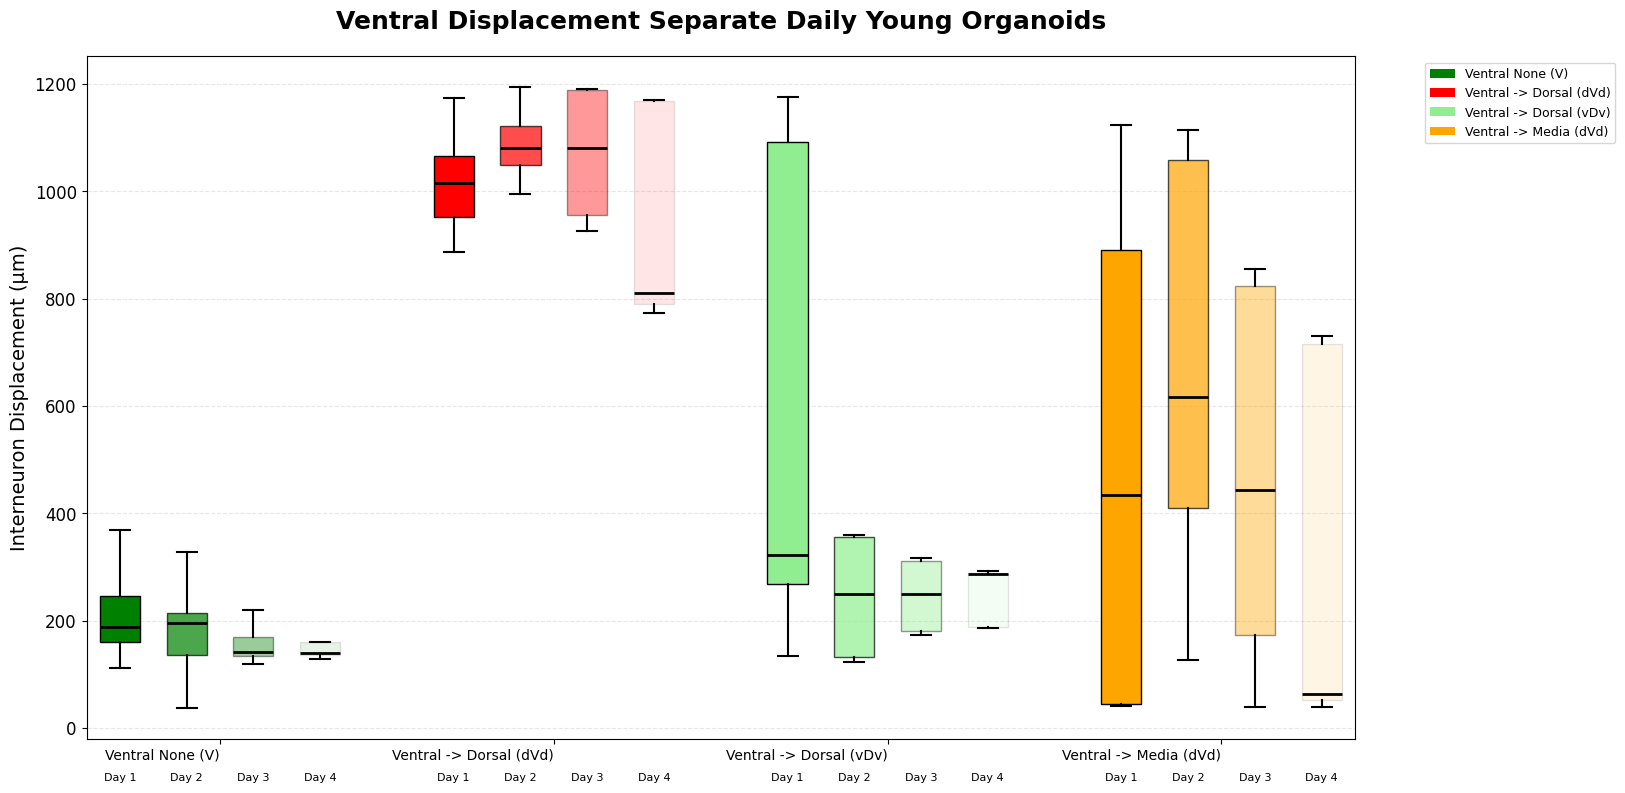


YOUNG ORGANOID VENTRAL DISPLACEMENT ANALYSIS COMPLETE


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ============================================================================
# STANDARDIZED PLOT CONFIGURATION
# ============================================================================
PLOT_CONFIG = {
    'figsize': (16, 8),
    'title_fontsize': 18,
    'title_weight': 'bold',
    'title_pad': 20,
    'label_fontsize': 14,
    'tick_fontsize': 12,
    'xtick_fontsize': 10,
    'legend_fontsize': 9,
    'box_width': 0.6,
    'line_width': 1.5,
    'median_width': 2,
    'dpi': 300,
    'alpha': 0.7,
    'grid_alpha': 0.3
}

# Load data
df = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')

# Clean column names by removing extra spaces
df.columns = [col.strip() for col in df.columns]

# Define time periods for each day (each day = 24 hours)
day1 = (0, 24)    # 0-24 hours
day2 = (24, 48)   # 24-48 hours
day3 = (48, 72)   # 48-72 hours
day4 = (72, 96)   # 72-96 hours

# Prepare data structure with condition information
conditions = {
    'Ventral None (V)': {
        'prefix': 'Condition#1 VentralOnly Green',
        'color': 'green'
    },
    'Ventral -> Dorsal (dVd)': {
        'prefix': 'Condition#2 VentralCenter Green',
        'color': 'red'
    },
    'Ventral -> Dorsal (vDv)': {
        'prefix': 'Condition#4 Dorsal Center Green',
        'color': 'lightgreen'
    },
    'Ventral -> Media (dVd)': {
        'prefix': 'Condition#2 VentralCenter toward media',
        'color': 'orange'
    },
}

# Create a figure with standardized dimensions
fig = plt.figure(figsize=PLOT_CONFIG['figsize'])

# Store colors for legend
box_colors = [cond_info['color'] for cond_info in conditions.values()]

# For each condition, extract data for each day and create boxplots
for i, (cond_name, cond_info) in enumerate(conditions.items()):
    # Get all columns for this condition
    cols = [col for col in df.columns if cond_info['prefix'] in col]

    if not cols:
        print(f"Warning: No columns found for {cond_name}")
        continue

    print(f"Processing {cond_name} with columns: {cols}")

    # Extract data for each day
    day1_data = df[(df['Time (hr)'] >= day1[0]) & (df['Time (hr)'] < day1[1])][cols].values.flatten()
    day2_data = df[(df['Time (hr)'] >= day2[0]) & (df['Time (hr)'] < day2[1])][cols].values.flatten()
    day3_data = df[(df['Time (hr)'] >= day3[0]) & (df['Time (hr)'] < day3[1])][cols].values.flatten()
    day4_data = df[(df['Time (hr)'] >= day4[0]) & (df['Time (hr)'] < day4[1])][cols].values.flatten()

    # Remove NaN values
    day1_data = day1_data[~np.isnan(day1_data)]
    day2_data = day2_data[~np.isnan(day2_data)]
    day3_data = day3_data[~np.isnan(day3_data)]
    day4_data = day4_data[~np.isnan(day4_data)]

    print(f"{cond_name} - Day 1 data points: {len(day1_data)}")
    print(f"{cond_name} - Day 2 data points: {len(day2_data)}")
    print(f"{cond_name} - Day 3 data points: {len(day3_data)}")
    print(f"{cond_name} - Day 4 data points: {len(day4_data)}")

    # Create positions for boxplots (grouped by condition)
    positions = [i*5, i*5+1, i*5+2, i*5+3]  # Changed spacing to 5 for consistency

    # Get the color for this condition
    base_color = cond_info['color']

    # Create boxplots with different transparency for each day - standardized parameters
    if len(day1_data) > 0:
        plt.boxplot(day1_data, positions=[positions[0]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=1.0, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

    if len(day2_data) > 0:
        plt.boxplot(day2_data, positions=[positions[1]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=0.7, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

    if len(day3_data) > 0:
        plt.boxplot(day3_data, positions=[positions[2]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=0.4, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

    if len(day4_data) > 0:
        plt.boxplot(day4_data, positions=[positions[3]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=0.1, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

# Customize the plot with standardized fonts
plt.title('Ventral Displacement Separate Daily Young Organoids',
          fontsize=PLOT_CONFIG['title_fontsize'],
          fontweight=PLOT_CONFIG['title_weight'],
          pad=PLOT_CONFIG['title_pad'])
plt.ylabel('Interneuron Displacement (μm)', fontsize=PLOT_CONFIG['label_fontsize'])

# Set x-ticks and labels with standardized font size
xticks = [i*5+1.5 for i in range(len(conditions))]
plt.xticks(xticks, conditions.keys(), rotation=0, ha='right',
           fontsize=PLOT_CONFIG['xtick_fontsize'])
plt.yticks(fontsize=PLOT_CONFIG['tick_fontsize'])

# Add day indicators below x-axis with standardized font size
y_min, y_max = plt.ylim()
for i, cond in enumerate(conditions):
    plt.text(i*5+0, y_min - 0.05*(y_max-y_min), 'Day 1',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')
    plt.text(i*5+1, y_min - 0.05*(y_max-y_min), 'Day 2',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')
    plt.text(i*5+2, y_min - 0.05*(y_max-y_min), 'Day 3',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')
    plt.text(i*5+3, y_min - 0.05*(y_max-y_min), 'Day 4',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')

# Create legend with standardized font size
legend_elements = [Patch(facecolor=box_colors[i], label=list(conditions.keys())[i])
                  for i in range(len(conditions))]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=PLOT_CONFIG['legend_fontsize'])

# Add grid and adjust layout with standardized alpha
plt.grid(True, axis='y', linestyle='--', alpha=PLOT_CONFIG['grid_alpha'])
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Consistent margin for legend

plt.show()

# Optional: Save with standardized DPI
# plt.savefig('young_ventral_displacement.png', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')

print("\n" + "=" * 80)
print("YOUNG ORGANOID VENTRAL DISPLACEMENT ANALYSIS COMPLETE")
print("=" * 80)

p-value comparison

/tmp/ipython-input-657939350.py:127: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


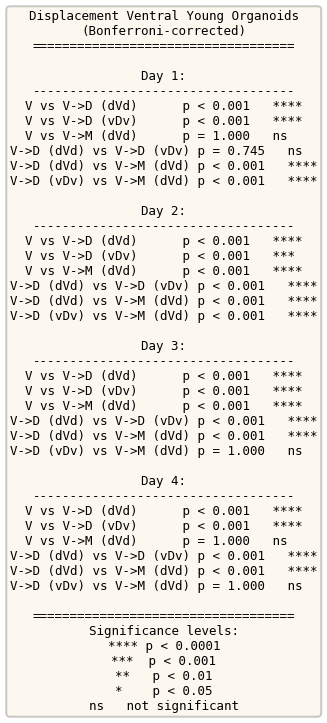

In [ ]:
# ======================================================================
# CREATE SEPARATE 6x6 P-VALUE LEGEND FIGURE
# ======================================================================
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations

# Prepare all comparisons
all_p_values = []
all_comparisons = []
all_data_dict = {}

condition_abbrev = {
    'Ventral None (V)': 'V',
    'Ventral -> Dorsal (dVd)': 'V->D (dVd)',
    'Ventral -> Dorsal (vDv)': 'V->D (vDv)',
    'Ventral -> Media (dVd)': 'V->M (dVd)'
}

# Store data for each condition and day
day_ranges_dict = {'day1': day1, 'day2': day2, 'day3': day3, 'day4': day4}

for cond_name, cond_info in conditions.items():
    all_data_dict[cond_name] = {}
    cols = [col for col in df.columns if cond_info['prefix'] in col]

    for day_key, (t0, t1) in day_ranges_dict.items():
        data = df[(df['Time (hr)'] >= t0) & (df['Time (hr)'] < t1)][cols].values.flatten()
        data = data[~np.isnan(data)]
        all_data_dict[cond_name][day_key] = data

# Collect p-values for all day/condition pairs
for day_idx, day_key in enumerate(day_ranges_dict.keys()):
    for condA, condB in combinations(conditions.keys(), 2):
        dataA = all_data_dict[condA][day_key]
        dataB = all_data_dict[condB][day_key]

        if len(dataA) > 0 and len(dataB) > 0:
            stat, p = mannwhitneyu(dataA, dataB, alternative='two-sided')
            all_p_values.append(p)
            all_comparisons.append({
                'day': day_idx + 1,
                'condA': condition_abbrev[condA],
                'condB': condition_abbrev[condB]
            })

# Bonferroni correction
if len(all_p_values) > 0:
    reject, p_corrected, _, _ = multipletests(all_p_values, method='bonferroni')

    # Create 6x6 figure for p-values
    fig_pval = plt.figure(figsize=(3, 3))
    ax_pval = fig_pval.add_subplot(111)

    # Remove axes
    ax_pval.axis('off')

    # Build text content
    p_text_lines = []
    p_text_lines.append("Displacement Ventral Young Organoids")
    p_text_lines.append("(Bonferroni-corrected)")
    p_text_lines.append("=" * 35)
    p_text_lines.append("")

    ptr = 0
    for day_num in range(1, 5):
        day_comps = [c for c in all_comparisons if c['day'] == day_num]

        if day_comps:
            p_text_lines.append(f"Day {day_num}:")
            p_text_lines.append("-" * 35)

            for comp in day_comps:
                p_corr = p_corrected[ptr]

                # Determine significance stars
                if p_corr < 0.0001:
                    stars = '****'
                elif p_corr < 0.001:
                    stars = '***'
                elif p_corr < 0.01:
                    stars = '**'
                elif p_corr < 0.05:
                    stars = '*'
                else:
                    stars = 'ns'

                # Format p-value
                if p_corr < 0.001:
                    p_str = "p < 0.001"
                else:
                    p_str = f"p = {p_corr:.3f}"

                # Create formatted line
                comp_label = f"{comp['condA']} vs {comp['condB']}"
                line = f"{comp_label:20s} {p_str:11s} {stars:4s}"
                p_text_lines.append(line)

                ptr += 1

            p_text_lines.append("")

    # Add legend
    p_text_lines.append("=" * 35)
    p_text_lines.append("Significance levels:")
    p_text_lines.append("**** p < 0.0001")
    p_text_lines.append("***  p < 0.001")
    p_text_lines.append("**   p < 0.01")
    p_text_lines.append("*    p < 0.05")
    p_text_lines.append("ns   not significant")

    # Join all lines
    p_value_text = '\n'.join(p_text_lines)

    # Add text to figure with box
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.2,
                 edgecolor='black', linewidth=1.5)

    ax_pval.text(0.5, 0.5, p_value_text,
                transform=ax_pval.transAxes,
                fontsize=9,
                verticalalignment='center',
                horizontalalignment='center',
                fontfamily='monospace',
                bbox=props)

    plt.tight_layout()

NameError: name 'day_legend' is not defined

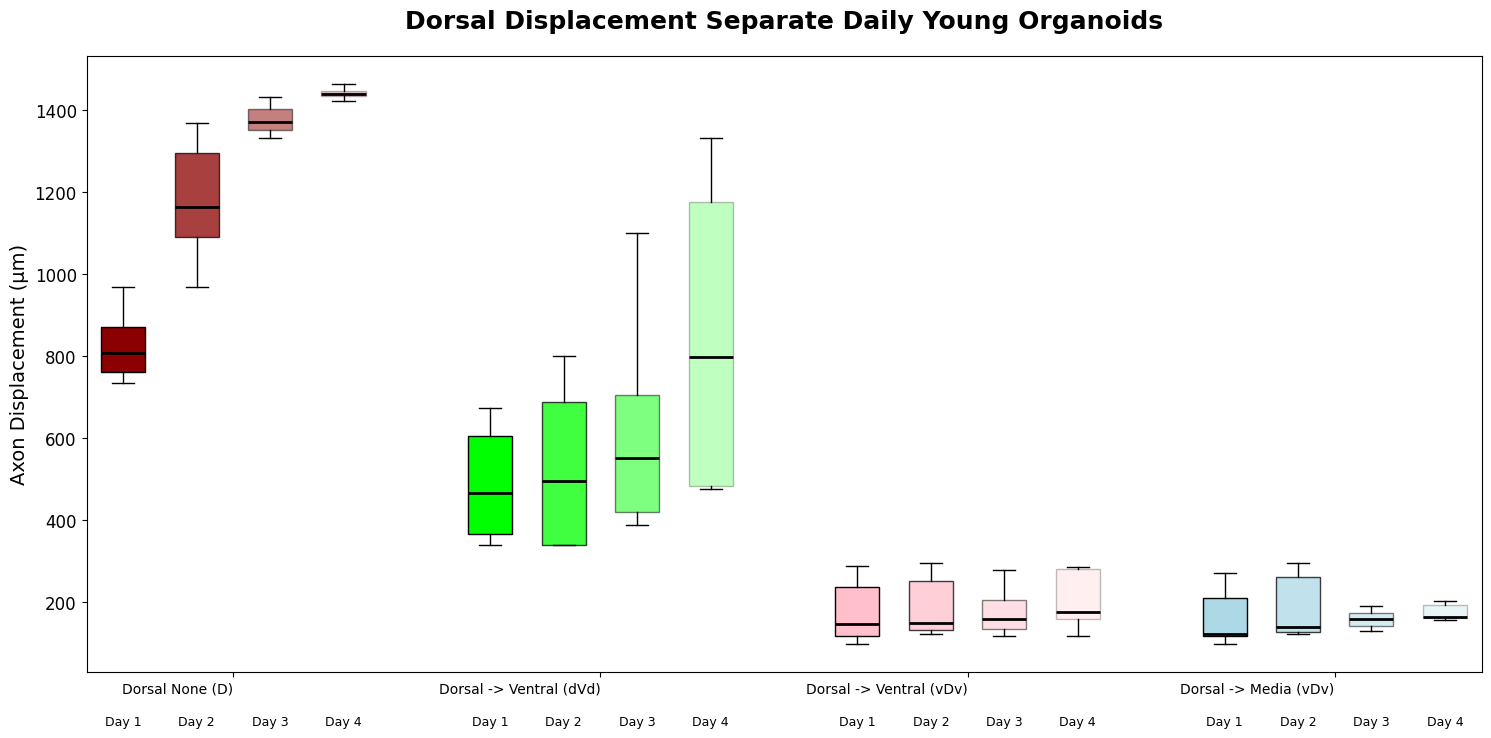

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Load data
df = pd.read_excel('Data 1.xlsx')

PLOT_CONFIG = {
    'figsize': (16, 8),
    'title_fontsize': 18,
    'title_weight': 'bold',
    'title_pad': 20,
    'label_fontsize': 14,
    'tick_fontsize': 12,
    'xtick_fontsize': 10,
    'legend_fontsize': 9,
    'box_width': 0.6,
    'line_width': 1.5,
    'median_width': 2,
    'dpi': 300,
    'alpha': 0.7,
    'grid_alpha': 0.3
}


# Define time periods for each day (each day = 24 hours)
days = {
    'Day 1': (0, 24),
    'Day 2': (24, 48),
    'Day 3': (48, 72),
    'Day 4': (72, 96)
}

# Prepare condition information with colors and alpha values
conditions = {
    'Dorsal None (D)': {
        'prefix': 'Condition#3 Dorsal Only Red',
        'color': 'darkred'
    },
    'Dorsal -> Ventral (dVd)': {
        'prefix': 'Condition#2 VentralCenter Red',
        'color': 'lime'
    },
    'Dorsal -> Ventral (vDv)': {
        'prefix': 'Condition#4 Dorsal Center Red',
        'color': 'pink'
    },
    'Dorsal -> Media (vDv)': {
        'prefix': 'Condition#4 Dorsal Center Red toward Media',
        'color': 'lightblue'
    }
}

# Create figure with adjusted size
plt.figure(figsize=(18, 8))

# Define alpha values for each day (more distinct progression)
day_alphas = {
    'Day 1': 1.0,
    'Day 2': 0.75,
    'Day 3': 0.5,
    'Day 4': 0.25
}

# Plot boxplots for each condition and day
for cond_idx, (cond_name, cond_info) in enumerate(conditions.items()):
    # Get relevant columns
    cols = [col for col in df.columns if cond_info['prefix'] in col]
    if not cols:
        continue

    # Plot each day
    for day_idx, (day_name, (day_start, day_end)) in enumerate(days.items()):
        # Extract and clean data
        day_data = df[(df['Time (hr)'] >= day_start) &
                    (df['Time (hr)'] < day_end)][cols].values.flatten()
        day_data = day_data[~np.isnan(day_data)]

        if len(day_data) > 0:
            position = cond_idx*5 + day_idx  # Increased spacing between conditions
            plt.boxplot(day_data,
                       positions=[position],
                       widths=0.6,
                       patch_artist=True,
                       boxprops=dict(
                           facecolor=cond_info['color'],
                           alpha=day_alphas[day_name],
                           edgecolor='black',
                           linewidth=1
                       ),
                       medianprops=dict(color='black', linewidth=2),
                       whiskerprops=dict(color='black', linewidth=1),
                       capprops=dict(color='black', linewidth=1),
                       showfliers=False)

# Customize plot appearance

plt.title('Dorsal Displacement Separate Daily Young Organoids',
          fontsize=PLOT_CONFIG['title_fontsize'],
          fontweight=PLOT_CONFIG['title_weight'],
          pad=PLOT_CONFIG['title_pad'])
plt.ylabel('Axon Displacement (μm)', fontsize=PLOT_CONFIG['label_fontsize'])


# Set x-ticks at the center of each condition group
xticks = [i*5 + 1.5 for i in range(len(conditions))]
plt.xticks(xticks, conditions.keys(), rotation=0, ha='right', fontsize=10)
plt.yticks(fontsize=12)

# Add day indicators below x-axis
y_min, y_max = plt.ylim()
label_y = y_min - 0.07 * (y_max - y_min)  # Position below axis

for cond_idx in range(len(conditions)):
    for day_idx, day_name in enumerate(days.keys()):
        plt.text(cond_idx*5 + day_idx, label_y, day_name,
                ha='center', va='top', fontsize=9, color='black')

# Create dual legend (conditions + days)
condition_legend = [Patch(facecolor=info['color'], label=name)
                   for name, info in conditions.items()]

# Place legends side by side
plt.legend(handles=condition_legend + day_legend,
           bbox_to_anchor=(1.05, 1),
           loc='upper left',
           ncol=2,
           fontsize=10)

# Adjust grid and layout
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()


P-value Comparison

/tmp/ipython-input-3443488832.py:125: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


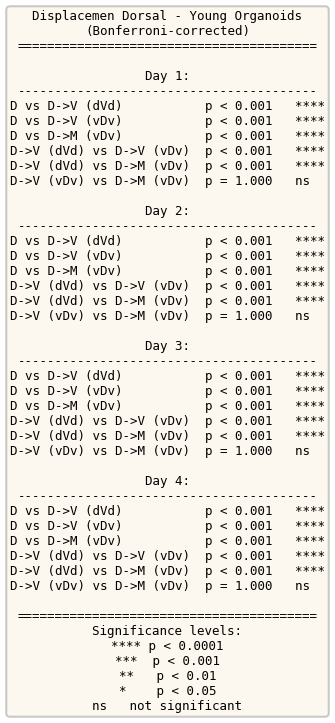


DORSAL CONDITIONS STATISTICAL SUMMARY
Total comparisons: 24
Significant comparisons (p < 0.05): 20

By Day:
  Day 1: 5/6 significant
  Day 2: 5/6 significant
  Day 3: 5/6 significant
  Day 4: 5/6 significant


In [ ]:
# ======================================================================
# CREATE SEPARATE P-VALUE LEGEND FIGURE - DORSAL CONDITIONS
# ======================================================================
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations

# Prepare all comparisons
all_p_values = []
all_comparisons = []
all_data_dict = {}

condition_abbrev = {
    'Dorsal None (D)': 'D',
    'Dorsal -> Ventral (dVd)': 'D->V (dVd)',
    'Dorsal -> Ventral (vDv)': 'D->V (vDv)',
    'Dorsal -> Media (vDv)': 'D->M (vDv)'  # Fixed: was (dVd), should match your conditions
}


for cond_name, cond_info in conditions.items():
    all_data_dict[cond_name] = {}
    cols = [col for col in df.columns if cond_info['prefix'] in col]

    for day_key, (t0, t1) in day_ranges_dict.items():
        data = df[(df['Time (hr)'] >= t0) & (df['Time (hr)'] < t1)][cols].values.flatten()
        data = data[~np.isnan(data)]
        all_data_dict[cond_name][day_key] = data

# Collect p-values for all day/condition pairs
for day_idx, day_key in enumerate(day_ranges_dict.keys()):
    for condA, condB in combinations(conditions.keys(), 2):  # Fixed: was condC, condD
        dataA = all_data_dict[condA][day_key]
        dataB = all_data_dict[condB][day_key]

        if len(dataA) > 0 and len(dataB) > 0:
            stat, p = mannwhitneyu(dataA, dataB, alternative='two-sided')
            all_p_values.append(p)
            all_comparisons.append({
                'day': day_idx + 1,
                'condA': condition_abbrev[condA],  # Fixed: was condC
                'condB': condition_abbrev[condB]   # Fixed: was referencing undefined condB in wrong place
            })

# Bonferroni correction
if len(all_p_values) > 0:
    reject, p_corrected, _, _ = multipletests(all_p_values, method='bonferroni')

    # Create 6x6 figure for p-values
    fig_pval = plt.figure(figsize=(3, 3))  # Changed to 6x6 as requested
    ax_pval = fig_pval.add_subplot(111)

    # Remove axes
    ax_pval.axis('off')

    # Build text content
    p_text_lines = []
    p_text_lines.append("Displacemen Dorsal - Young Organoids")
    p_text_lines.append("(Bonferroni-corrected)")
    p_text_lines.append("=" * 40)
    p_text_lines.append("")

    ptr = 0
    for day_num in range(1, 5):
        day_comps = [c for c in all_comparisons if c['day'] == day_num]

        if day_comps:
            p_text_lines.append(f"Day {day_num}:")
            p_text_lines.append("-" * 40)

            for comp in day_comps:
                p_corr = p_corrected[ptr]

                # Determine significance stars
                if p_corr < 0.0001:
                    stars = '****'
                elif p_corr < 0.001:
                    stars = '***'
                elif p_corr < 0.01:
                    stars = '**'
                elif p_corr < 0.05:
                    stars = '*'
                else:
                    stars = 'ns'

                # Format p-value
                if p_corr < 0.001:
                    p_str = "p < 0.001"
                else:
                    p_str = f"p = {p_corr:.3f}"

                # Create formatted line
                comp_label = f"{comp['condA']} vs {comp['condB']}"
                line = f"{comp_label:25s} {p_str:11s} {stars:4s}"
                p_text_lines.append(line)

                ptr += 1

            p_text_lines.append("")

    # Add legend
    p_text_lines.append("=" * 40)
    p_text_lines.append("Significance levels:")
    p_text_lines.append("**** p < 0.0001")
    p_text_lines.append("***  p < 0.001")
    p_text_lines.append("**   p < 0.01")
    p_text_lines.append("*    p < 0.05")
    p_text_lines.append("ns   not significant")

    # Join all lines
    p_value_text = '\n'.join(p_text_lines)

    # Add text to figure with box
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.2,
                 edgecolor='black', linewidth=1.5)

    ax_pval.text(0.5, 0.5, p_value_text,
                transform=ax_pval.transAxes,
                fontsize=9,
                verticalalignment='center',
                horizontalalignment='center',
                fontfamily='monospace',
                bbox=props)

    plt.tight_layout()

    # Save the figure
    plt.savefig('dorsal_pvalue_legend_6x6.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Display summary statistics
    print("\n" + "="*60)
    print("DORSAL CONDITIONS STATISTICAL SUMMARY")
    print("="*60)
    print(f"Total comparisons: {len(all_p_values)}")
    print(f"Significant comparisons (p < 0.05): {sum(reject)}")
    print("\nBy Day:")

    ptr = 0
    for day_num in range(1, 5):
        day_comps = [c for c in all_comparisons if c['day'] == day_num]
        if day_comps:
            day_reject = reject[ptr:ptr+len(day_comps)]
            print(f"  Day {day_num}: {sum(day_reject)}/{len(day_comps)} significant")
            ptr += len(day_comps)
    print("="*60)

## Young Organoid Velocity Graphs

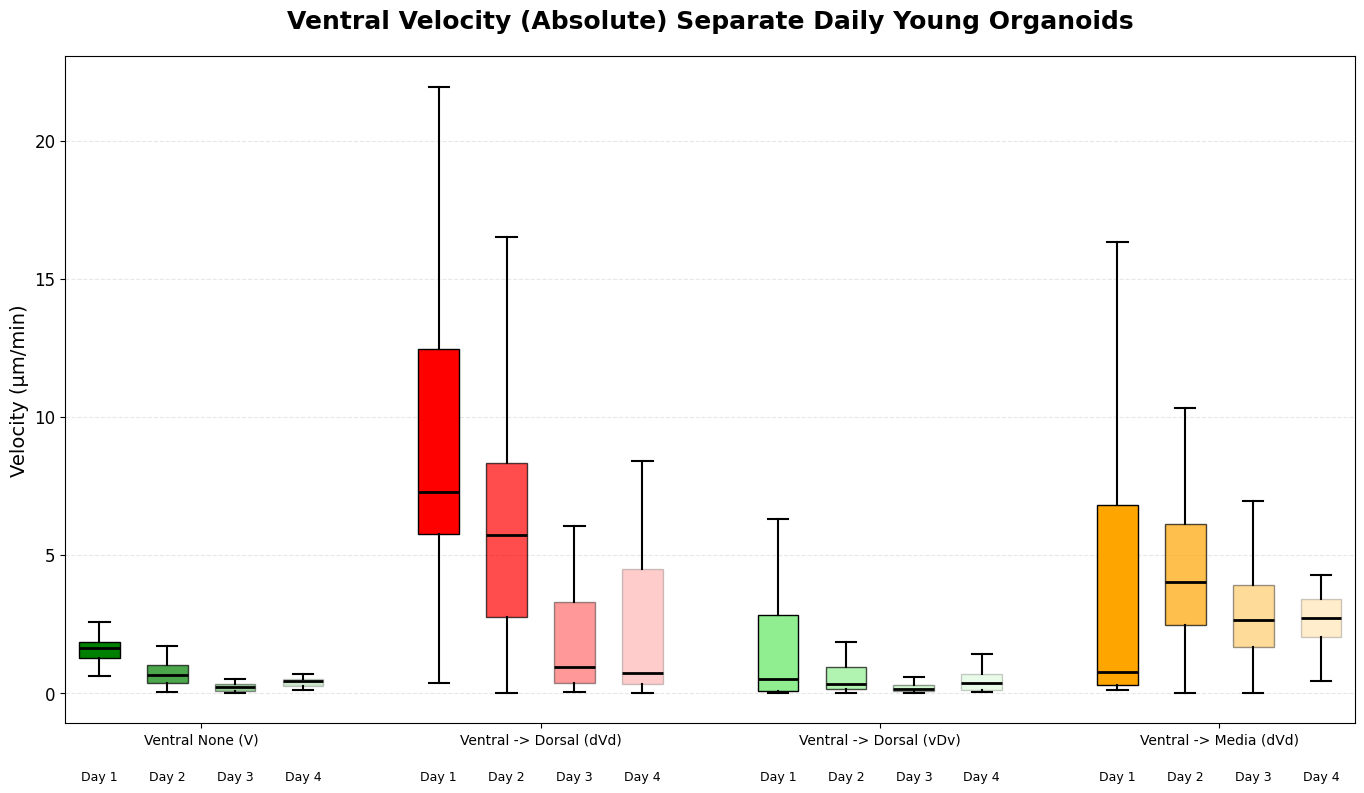

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ============================================================================
# STANDARDIZED PLOT CONFIGURATION
# ============================================================================
PLOT_CONFIG = {
    'figsize': (16, 8),
    'title_fontsize': 18,
    'title_weight': 'bold',
    'title_pad': 20,
    'label_fontsize': 14,
    'tick_fontsize': 12,
    'xtick_fontsize': 10,
    'legend_fontsize': 9,
    'box_width': 0.6,
    'line_width': 1.5,
    'median_width': 2,
    'dpi': 300,
    'alpha': 0.7,
    'grid_alpha': 0.3
}

# Load the Excel file
df = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')

# Clean column names by removing extra spaces
df.columns = [col.strip() for col in df.columns]

# Define time periods for each day (each day = 24 hours)
day_ranges = {
    'day1': (0, 24),
    'day2': (24, 48),
    'day3': (48, 72),
    'day4': (72, 96)
}
day_labels = list(day_ranges.keys())

# Define the conditions dictionary with color information
conditions = {
    'Ventral None (V)': {
        'columns': [
            'Velocity C1: Ventral Only',
            'Velocity C1: VentralOnly',
            'Velocity: C1 Ventral Only'
        ],
        'color': 'green'
    },
    'Ventral -> Dorsal (dVd)': {
        'columns': [
            'Velocity: C2 VentralCenter Green',
            'Velocity: C2 Ventral Center Green'
        ],
        'color': 'red'
    },
    'Ventral -> Dorsal (vDv)': {
        'columns': [
            'Velocity: C4 Dorsal Center Red'
        ],
        'color': 'lightgreen'
    },
    'Ventral -> Media (dVd)': {
        'columns': [
            'Velocity: C2 VentralCenter towards Media'
        ],
        'color': 'orange'
    },
}

# Function to remove outliers using IQR method with absolute values
def remove_outliers(data):
    data = np.asarray(data)
    data = np.abs(data)  # Take absolute value
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return data[(data >= lower_bound) & (data <= upper_bound)]

# ======================
# DATA EXTRACTION
# ======================
all_data = {cond: {} for cond in conditions}
sample_sizes = {cond: {} for cond in conditions}

for cond_name, cond_info in conditions.items():
    cols = []
    for col_pattern in cond_info['columns']:
        matching_cols = [col for col in df.columns if col_pattern in col]
        cols.extend(matching_cols)

    if not cols:
        print(f"⚠️ Warning: No matching columns found for '{cond_name}'.")
        for day_key in day_labels:
            all_data[cond_name][day_key] = np.array([])
            sample_sizes[cond_name][day_key] = 0
        continue

    for day_key, (t0, t1) in day_ranges.items():
        subset = df[(df['Time (hr)'] >= t0) & (df['Time (hr)'] < t1)][cols]
        values = subset.values.flatten()
        values = values[~np.isnan(values)]
        values = remove_outliers(values)
        all_data[cond_name][day_key] = values
        sample_sizes[cond_name][day_key] = len(values)

# ======================
# PLOTTING
# ======================
fig = plt.figure(figsize=PLOT_CONFIG['figsize'])
ax = plt.gca()

conditions_list = list(conditions.keys())
num_conditions = len(conditions_list)

# Define alpha values for each day
day_alphas = [1.0, 0.7, 0.4, 0.2]

# For each condition, extract data for each day and create boxplots
for i, (cond_name, cond_info) in enumerate(conditions.items()):
    for day_index, day_key in enumerate(day_labels):
        data = all_data[cond_name][day_key]

        if len(data) > 0:
            position = i * 5 + day_index  # 5 units spacing between conditions

            plt.boxplot(data, positions=[position], widths=0.6, patch_artist=True,
                         boxprops=dict(facecolor=cond_info['color'], alpha=day_alphas[day_index], edgecolor='black'),
                         medianprops=dict(color='black', linewidth=2),
                         whiskerprops=dict(color='black', linewidth=1.5),
                         capprops=dict(color='black', linewidth=1.5),
                         showfliers=False)

# Customize the plot
plt.title('Ventral Velocity (Absolute) Separate Daily Young Organoids',
          fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Velocity (μm/min)', fontsize=14)

# Set x-ticks and labels
xticks = [i * 5 + 1.5 for i in range(num_conditions)]
plt.xticks(xticks, conditions_list, fontsize=10)
plt.yticks(fontsize=12)

# Add day indicators below x-axis
y_min, y_max = plt.ylim()
label_y = y_min - 0.07 * (y_max - y_min)  # Position below axis

for cond_idx in range(num_conditions):
    for day_idx in range(4):
        plt.text(cond_idx * 5 + day_idx, label_y, f'Day {day_idx + 1}',
                ha='center', va='top', fontsize=9, color='black')

# ======================
# LEGENDS
# ======================
# Condition legend
legend_elements = [Patch(facecolor=cond_info['color'], label=cond_name)
                  for cond_name, cond_info in conditions.items()]

legend1 = plt.legend(handles=legend_elements,
                    bbox_to_anchor=(1.05, 1),
                    loc='upper left',
                    title='Conditions',
                    fontsize=9,
                    title_fontsize=10)

ax.add_artist(legend1)

# Day legend
day_legend = [Patch(facecolor='gray', alpha=day_alphas[i], label=f'Day {i+1}')
              for i in range(4)]

legend2 = plt.legend(handles=day_legend,
                    bbox_to_anchor=(1.05, 0.75),
                    loc='upper left',
                    title='Time Period',
                    fontsize=9,
                    title_fontsize=10)

ax.add_artist(legend2)

# Add grid and adjust layout
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.subplots_adjust(right=0.85)

plt.show()

p-value comparison

/tmp/ipython-input-2110257995.py:115: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


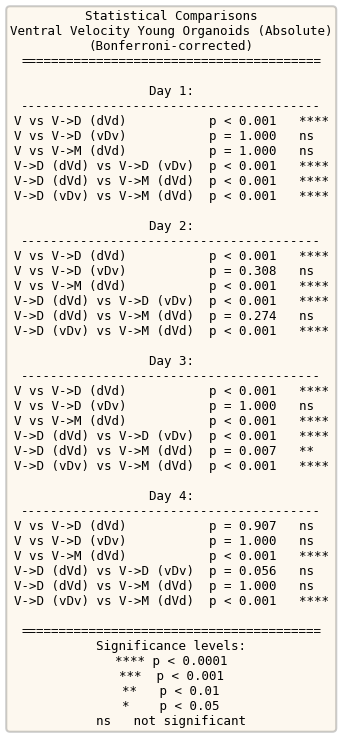


VENTRAL VELOCITY STATISTICAL SUMMARY
Total comparisons: 24
Significant comparisons (p < 0.05): 15

By Day:
  Day 1: 4/6 significant
  Day 2: 4/6 significant
  Day 3: 5/6 significant
  Day 4: 2/6 significant

Sample sizes by condition and day:
------------------------------------------------------------

Ventral None (V):
  day1: n=42
  day2: n=41
  day3: n=41
  day4: n=23

Ventral -> Dorsal (dVd):
  day1: n=87
  day2: n=89
  day3: n=88
  day4: n=40

Ventral -> Dorsal (vDv):
  day1: n=92
  day2: n=86
  day3: n=92
  day4: n=32

Ventral -> Media (dVd):
  day1: n=88
  day2: n=80
  day3: n=82
  day4: n=40


In [ ]:
# ======================================================================
# CREATE SEPARATE 6x6 P-VALUE LEGEND FIGURE - VENTRAL VELOCITY
# ======================================================================
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations

# Prepare all comparisons
all_p_values = []
all_comparisons = []

condition_abbrev = {
    'Ventral None (V)': 'V',
    'Ventral -> Dorsal (dVd)': 'V->D (dVd)',
    'Ventral -> Dorsal (vDv)': 'V->D (vDv)',
    'Ventral -> Media (dVd)': 'V->M (dVd)'
}

# Collect p-values for all day/condition pairs
for day_idx, day_key in enumerate(day_labels):
    for condA, condB in combinations(conditions_list, 2):
        dataA = all_data[condA][day_key]
        dataB = all_data[condB][day_key]

        if len(dataA) > 0 and len(dataB) > 0:
            stat, p = mannwhitneyu(dataA, dataB, alternative='two-sided')
            all_p_values.append(p)
            all_comparisons.append({
                'day': day_idx + 1,
                'condA': condition_abbrev[condA],
                'condB': condition_abbrev[condB]
            })

# Bonferroni correction
if len(all_p_values) > 0:
    reject, p_corrected, _, _ = multipletests(all_p_values, method='bonferroni')

    # Create 6x6 figure for p-values
    fig_pval = plt.figure(figsize=(3, 3))
    ax_pval = fig_pval.add_subplot(111)

    # Remove axes
    ax_pval.axis('off')

    # Build text content
    p_text_lines = []
    p_text_lines.append("Statistical Comparisons")
    p_text_lines.append("Ventral Velocity Young Organoids (Absolute)")
    p_text_lines.append("(Bonferroni-corrected)")
    p_text_lines.append("=" * 40)
    p_text_lines.append("")

    ptr = 0
    for day_num in range(1, 5):
        day_comps = [c for c in all_comparisons if c['day'] == day_num]

        if day_comps:
            p_text_lines.append(f"Day {day_num}:")
            p_text_lines.append("-" * 40)

            for comp in day_comps:
                p_corr = p_corrected[ptr]

                # Determine significance stars
                if p_corr < 0.0001:
                    stars = '****'
                elif p_corr < 0.001:
                    stars = '***'
                elif p_corr < 0.01:
                    stars = '**'
                elif p_corr < 0.05:
                    stars = '*'
                else:
                    stars = 'ns'

                # Format p-value
                if p_corr < 0.001:
                    p_str = "p < 0.001"
                else:
                    p_str = f"p = {p_corr:.3f}"

                # Create formatted line
                comp_label = f"{comp['condA']} vs {comp['condB']}"
                line = f"{comp_label:25s} {p_str:11s} {stars:4s}"
                p_text_lines.append(line)

                ptr += 1

            p_text_lines.append("")

    # Add legend
    p_text_lines.append("=" * 40)
    p_text_lines.append("Significance levels:")
    p_text_lines.append("**** p < 0.0001")
    p_text_lines.append("***  p < 0.001")
    p_text_lines.append("**   p < 0.01")
    p_text_lines.append("*    p < 0.05")
    p_text_lines.append("ns   not significant")

    # Join all lines
    p_value_text = '\n'.join(p_text_lines)

    # Add text to figure with box
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.2,
                 edgecolor='black', linewidth=1.5)

    ax_pval.text(0.5, 0.5, p_value_text,
                transform=ax_pval.transAxes,
                fontsize=9,
                verticalalignment='center',
                horizontalalignment='center',
                fontfamily='monospace',
                bbox=props)

    plt.tight_layout()

    # Save the figure
    plt.savefig('ventral_velocity_pvalue_legend_6x6.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Display summary statistics
    print("\n" + "="*60)
    print("VENTRAL VELOCITY STATISTICAL SUMMARY")
    print("="*60)
    print(f"Total comparisons: {len(all_p_values)}")
    print(f"Significant comparisons (p < 0.05): {sum(reject)}")
    print("\nBy Day:")

    ptr = 0
    for day_num in range(1, 5):
        day_comps = [c for c in all_comparisons if c['day'] == day_num]
        if day_comps:
            day_reject = reject[ptr:ptr+len(day_comps)]
            print(f"  Day {day_num}: {sum(day_reject)}/{len(day_comps)} significant")
            ptr += len(day_comps)

    print("\nSample sizes by condition and day:")
    print("-"*60)
    for cond_name in conditions_list:
        print(f"\n{cond_name}:")
        for day_key in day_labels:
            n = sample_sizes[cond_name][day_key]
            print(f"  {day_key}: n={n}")
    print("="*60)

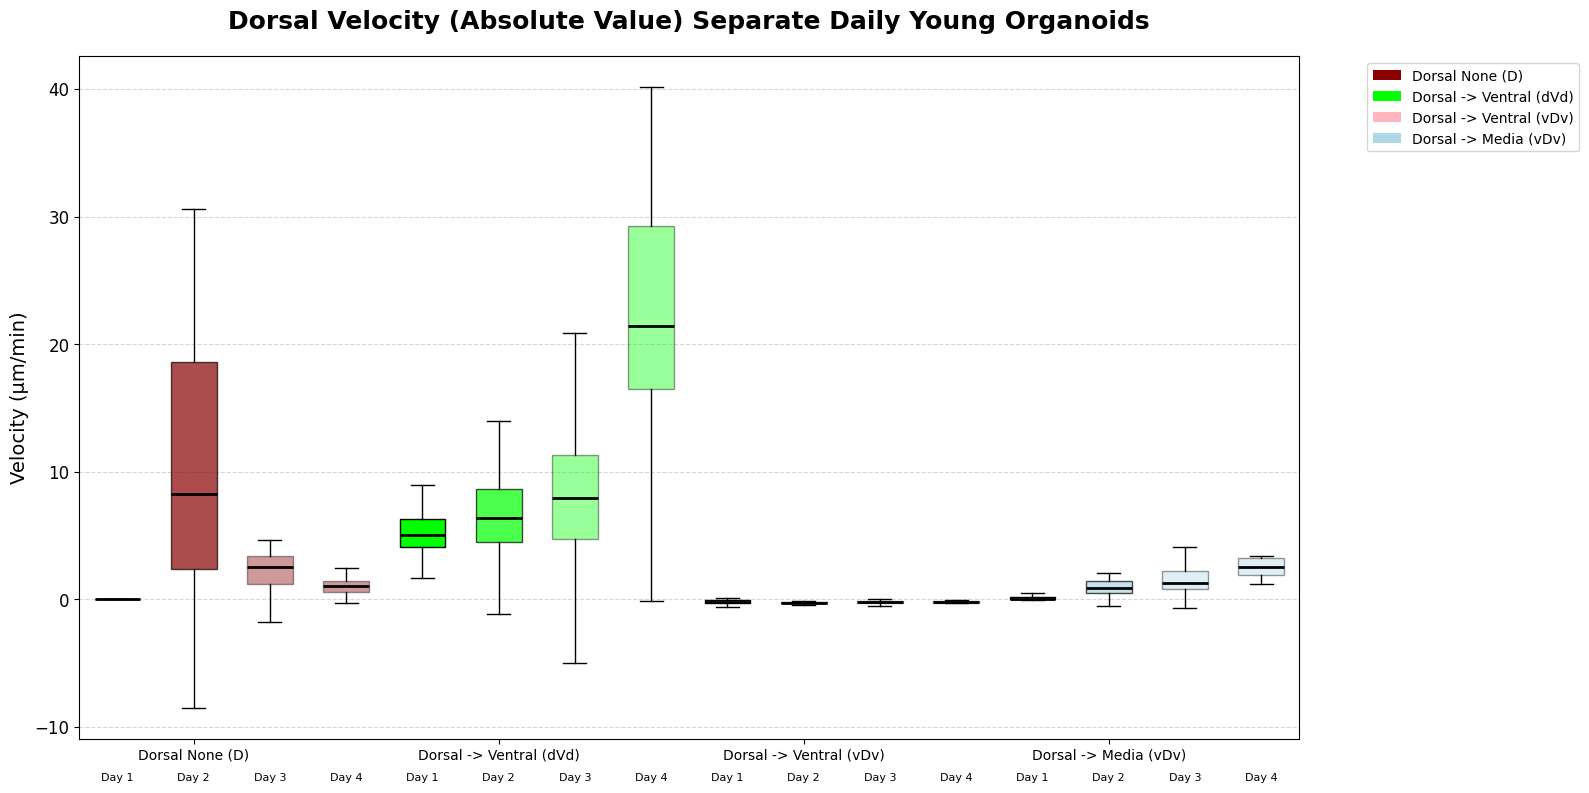

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Load the Excel file
df = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')

# Clean column names by removing extra spaces
df.columns = [col.strip() for col in df.columns]

# Define time periods for each day (each day = 24 hours)
day1 = (0, 24)    # 0-24 hours
day2 = (24, 48)   # 24-48 hours
day3 = (48, 72)   # 48-72 hours
day4= (72,96)

PLOT_CONFIG = {
    'figsize': (16, 8),
    'title_fontsize': 18,
    'title_weight': 'bold',
    'title_pad': 20,
    'label_fontsize': 14,
    'tick_fontsize': 12,
    'xtick_fontsize': 10,
    'legend_fontsize': 9,
    'box_width': 0.6,
    'line_width': 1.5,
    'median_width': 2,
    'dpi': 300,
    'alpha': 0.7,
    'grid_alpha': 0.3
}

# Define the conditions dictionary with color information
conditions = {
    'Dorsal None (D)': {
        'columns': [
            'Velocity: C3 Dorsal Only Red'
        ],
        'color': 'darkred'
    },
    # 6. Dorsal -> Ventral (dVd)
    'Dorsal -> Ventral (dVd)': {
        'columns': [
            'C2 VentralCenter Red'
        ],
        'color': 'lime'
    },
    # 7. Dorsal -> Ventral (vDv)
    'Dorsal -> Ventral (vDv)': {
        'columns': [
            'Velocity C4:DorsalCenter Green'
        ],
        'color': 'lightpink'
    },
    # 8. Dorsal -> Media (vDv)
    'Dorsal -> Media (vDv)': {
        'columns': [
            'Velocity: C4 DorsalCenter towards Media'
        ],
        'color': 'lightblue'
    }
}

# Function to remove outliers using IQR method
def remove_outliers(data):
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return data[(data >= lower_bound) & (data <= upper_bound)]

plt.figure(figsize=(16, 8))  # Increased width to accommodate all conditions

# For each condition, extract data for each day and create boxplots
for i, (cond_name, cond_info) in enumerate(conditions.items()):
    # Get all valid columns for this condition that exist in the dataframe
    cols = [col for col in cond_info['columns'] if col in df.columns]

    if not cols:  # Skip if no valid columns found
        continue

    # Extract data for each day
    day1_data = (df[(df['Time (hr)'] >= day1[0]) & (df['Time (hr)'] < day1[1])][cols].values.flatten())
    day2_data = (df[(df['Time (hr)'] >= day2[0]) & (df['Time (hr)'] < day2[1])][cols].values.flatten())
    day3_data = (df[(df['Time (hr)'] >= day3[0]) & (df['Time (hr)'] < day3[1])][cols].values.flatten())
    day4_data =(df[(df['Time (hr)'] >= day4[0]) & (df['Time (hr)'] < day4[1])][cols].values.flatten())

    # Remove NaN values and outliers
    day1_data = remove_outliers(day1_data[~np.isnan(day1_data)])
    day2_data = remove_outliers(day2_data[~np.isnan(day2_data)])
    day3_data = remove_outliers(day3_data[~np.isnan(day3_data)])
    day4_data= remove_outliers(day4_data[~np.isnan(day4_data)])

    # Create positions for boxplots (grouped by condition)
    positions = [i*4, i*4+1, i*4+2, i*4+3]

    # Get the color for this condition
    base_color = cond_info['color']

    # Create boxplots with different transparency for each day
    if len(day1_data) > 0:
        bp1 = plt.boxplot(day1_data, positions=[positions[0]], widths=0.6, patch_artist=True,
                         boxprops=dict(facecolor=base_color, alpha=1.0, edgecolor='black'),
                         medianprops=dict(color='black', linewidth=2),
                         whiskerprops=dict(color='black'),
                         capprops=dict(color='black'),
                         showfliers=False)

    if len(day2_data) > 0:
        bp2 = plt.boxplot(day2_data, positions=[positions[1]], widths=0.6, patch_artist=True,
                         boxprops=dict(facecolor=base_color, alpha=0.7, edgecolor='black'),
                         medianprops=dict(color='black', linewidth=2),
                         whiskerprops=dict(color='black'),
                         capprops=dict(color='black'),
                         showfliers=False)

    if len(day3_data) > 0:
        bp3 = plt.boxplot(day3_data, positions=[positions[2]], widths=0.6, patch_artist=True,
                         boxprops=dict(facecolor=base_color, alpha=0.4, edgecolor='black'),
                         medianprops=dict(color='black', linewidth=2),
                         whiskerprops=dict(color='black'),
                         capprops=dict(color='black'),
                         showfliers=False)
    if len(day4_data)>0:
        bp4=plt.boxplot(day4_data, positions=[positions[3]], widths=0.6, patch_artist=True,
                         boxprops=dict(facecolor=base_color, alpha=0.4, edgecolor='black'),
                         medianprops=dict(color='black', linewidth=2),
                         whiskerprops=dict(color='black'),
                         capprops=dict(color='black'),
                         showfliers=False)

# Customize the plot
plt.title('Dorsal Velocity (Absolute Value) Separate Daily Young Organoids',
          fontsize=PLOT_CONFIG['title_fontsize'],
          fontweight=PLOT_CONFIG['title_weight'],
          pad=PLOT_CONFIG['title_pad'])
plt.ylabel('Velocity (μm/min)', fontsize=PLOT_CONFIG['label_fontsize'])


# Set x-ticks and labels
xticks = [i*4+1 for i in range(len(conditions))]
plt.xticks(xticks, conditions.keys(), rotation=0, ha='center', fontsize=10)
plt.yticks(fontsize=12)

# Add day indicators below x-axis
for i, cond in enumerate(conditions):
    plt.text(i*4+0, plt.ylim()[0]-0.05*(plt.ylim()[1]-plt.ylim()[0]), 'Day 1',
             ha='center', va='top', fontsize=8, color='black')
    plt.text(i*4+1, plt.ylim()[0]-0.05*(plt.ylim()[1]-plt.ylim()[0]), 'Day 2',
             ha='center', va='top', fontsize=8, color='black')
    plt.text(i*4+2, plt.ylim()[0]-0.05*(plt.ylim()[1]-plt.ylim()[0]), 'Day 3',
             ha='center', va='top', fontsize=8, color='black')
    plt.text(i*4+3, plt.ylim()[0]-0.05*(plt.ylim()[1]-plt.ylim()[0]), 'Day 4',
             ha='center', va='top', fontsize=8, color='black')
# Create legend for conditions using their defined colors
legend_elements = [Patch(facecolor=cond_info['color'], label=cond_name)
                  for cond_name, cond_info in conditions.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid and adjust layout
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

p-value comparison

/tmp/ipython-input-1896903116.py:131: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


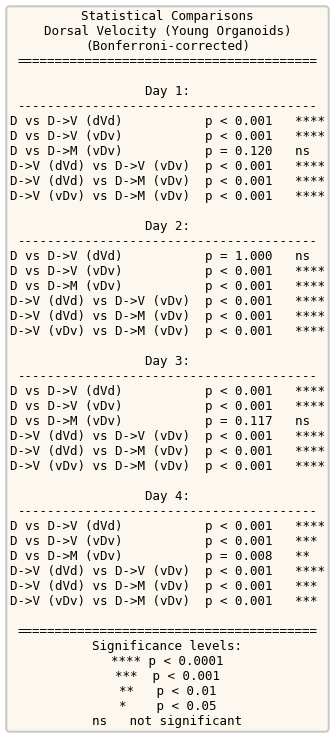


DORSAL VELOCITY (OLD ORGANOIDS) STATISTICAL SUMMARY
Total comparisons: 24
Significant comparisons (p < 0.05): 21

By Day:
  Day 1: 5/6 significant
  Day 2: 5/6 significant
  Day 3: 5/6 significant
  Day 4: 6/6 significant

Sample sizes by condition and day:
------------------------------------------------------------

Dorsal None (D):
  day1: n=27
  day2: n=48
  day3: n=47
  day4: n=22

Dorsal -> Ventral (dVd):
  day1: n=41
  day2: n=43
  day3: n=47
  day4: n=23

Dorsal -> Ventral (vDv):
  day1: n=42
  day2: n=41
  day3: n=44
  day4: n=12

Dorsal -> Media (vDv):
  day1: n=30
  day2: n=47
  day3: n=45
  day4: n=12


In [ ]:
# ======================================================================
# CREATE SEPARATE 6x6 P-VALUE LEGEND FIGURE - DORSAL VELOCITY (OLD)
# ======================================================================
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations

# Prepare all comparisons
all_p_values = []
all_comparisons = []
all_data_dict = {}

# Fixed condition abbreviations to match your actual condition names
condition_abbrev = {
    'Dorsal None (D)': 'D',
    'Dorsal -> Ventral (dVd)': 'D->V (dVd)',
    'Dorsal -> Ventral (vDv)': 'D->V (vDv)',
    'Dorsal -> Media (vDv)': 'D->M (vDv)'  # Fixed: was (dVd), should be (vDv)
}

# Store data for each condition and day
day_ranges_dict = {'day1': day1, 'day2': day2, 'day3': day3, 'day4': day4}
conditions_list = list(conditions.keys())

for cond_name, cond_info in conditions.items():
    all_data_dict[cond_name] = {}
    cols = [col for col in cond_info['columns'] if col in df.columns]

    for day_key, (t0, t1) in day_ranges_dict.items():
        data = df[(df['Time (hr)'] >= t0) & (df['Time (hr)'] < t1)][cols].values.flatten()
        data = data[~np.isnan(data)]
        data = remove_outliers(data)
        all_data_dict[cond_name][day_key] = data

# Collect p-values for all day/condition pairs
for day_idx, day_key in enumerate(day_ranges_dict.keys()):
    for condA, condB in combinations(conditions_list, 2):
        dataA = all_data_dict[condA][day_key]
        dataB = all_data_dict[condB][day_key]

        if len(dataA) > 0 and len(dataB) > 0:
            stat, p = mannwhitneyu(dataA, dataB, alternative='two-sided')
            all_p_values.append(p)
            all_comparisons.append({
                'day': day_idx + 1,
                'condA': condition_abbrev[condA],
                'condB': condition_abbrev[condB]
            })

# Bonferroni correction
if len(all_p_values) > 0:
    reject, p_corrected, _, _ = multipletests(all_p_values, method='bonferroni')

    # Create 6x6 figure for p-values
    fig_pval = plt.figure(figsize=(3, 3))
    ax_pval = fig_pval.add_subplot(111)

    # Remove axes
    ax_pval.axis('off')

    # Build text content
    p_text_lines = []
    p_text_lines.append("Statistical Comparisons")
    p_text_lines.append("Dorsal Velocity (Young Organoids)")
    p_text_lines.append("(Bonferroni-corrected)")
    p_text_lines.append("=" * 40)
    p_text_lines.append("")

    ptr = 0
    for day_num in range(1, 5):
        day_comps = [c for c in all_comparisons if c['day'] == day_num]

        if day_comps:
            p_text_lines.append(f"Day {day_num}:")
            p_text_lines.append("-" * 40)

            for comp in day_comps:
                p_corr = p_corrected[ptr]

                # Determine significance stars
                if p_corr < 0.0001:
                    stars = '****'
                elif p_corr < 0.001:
                    stars = '***'
                elif p_corr < 0.01:
                    stars = '**'
                elif p_corr < 0.05:
                    stars = '*'
                else:
                    stars = 'ns'

                # Format p-value
                if p_corr < 0.001:
                    p_str = "p < 0.001"
                else:
                    p_str = f"p = {p_corr:.3f}"

                # Create formatted line
                comp_label = f"{comp['condA']} vs {comp['condB']}"
                line = f"{comp_label:25s} {p_str:11s} {stars:4s}"
                p_text_lines.append(line)

                ptr += 1

            p_text_lines.append("")

    # Add legend
    p_text_lines.append("=" * 40)
    p_text_lines.append("Significance levels:")
    p_text_lines.append("**** p < 0.0001")
    p_text_lines.append("***  p < 0.001")
    p_text_lines.append("**   p < 0.01")
    p_text_lines.append("*    p < 0.05")
    p_text_lines.append("ns   not significant")

    # Join all lines
    p_value_text = '\n'.join(p_text_lines)

    # Add text to figure with box
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.2,
                 edgecolor='black', linewidth=1.5)

    ax_pval.text(0.5, 0.5, p_value_text,
                transform=ax_pval.transAxes,
                fontsize=9,
                verticalalignment='center',
                horizontalalignment='center',
                fontfamily='monospace',
                bbox=props)

    plt.tight_layout()

    # Save the figure
    plt.savefig('dorsal_velocity_old_pvalue_legend_6x6.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Display summary statistics
    print("\n" + "="*60)
    print("DORSAL VELOCITY (OLD ORGANOIDS) STATISTICAL SUMMARY")
    print("="*60)
    print(f"Total comparisons: {len(all_p_values)}")
    print(f"Significant comparisons (p < 0.05): {sum(reject)}")
    print("\nBy Day:")

    ptr = 0
    for day_num in range(1, 5):
        day_comps = [c for c in all_comparisons if c['day'] == day_num]
        if day_comps:
            day_reject = reject[ptr:ptr+len(day_comps)]
            print(f"  Day {day_num}: {sum(day_reject)}/{len(day_comps)} significant")
            ptr += len(day_comps)

    print("\nSample sizes by condition and day:")
    print("-"*60)
    for cond_name in conditions_list:
        print(f"\n{cond_name}:")
        for day_key in day_ranges_dict.keys():
            n = len(all_data_dict[cond_name][day_key])
            print(f"  {day_key}: n={n}")
    print("="*60)

## Displacement for Old organoids

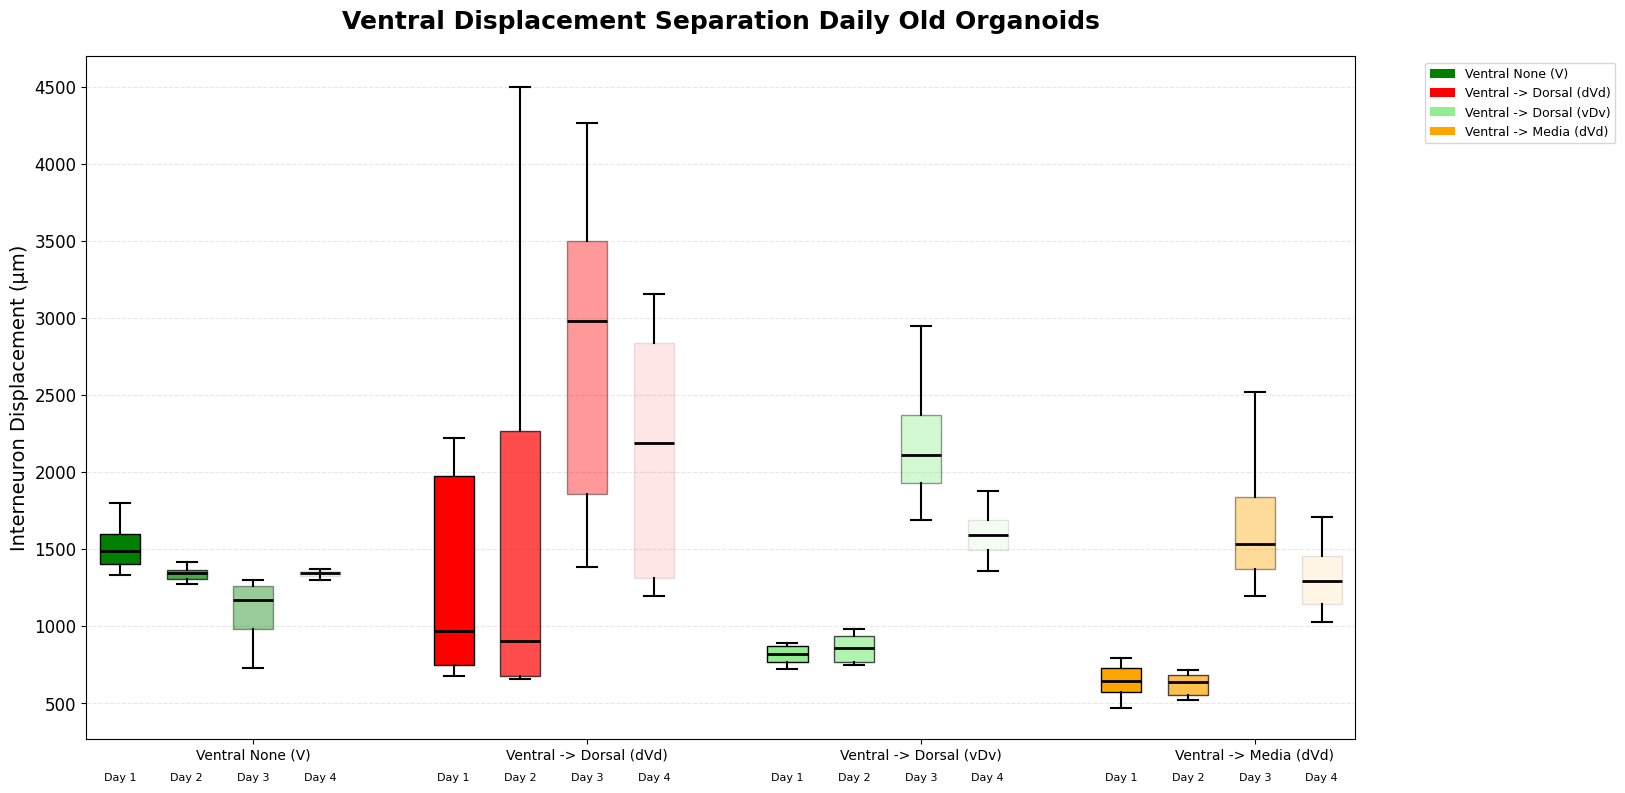

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from scipy import stats
import itertools

# ======================
# STANDARDIZED PLOT CONFIG
# ======================
PLOT_CONFIG = {
    'figsize': (16, 8),
    'title_fontsize': 18,
    'title_weight': 'bold',
    'title_pad': 20,
    'label_fontsize': 14,
    'tick_fontsize': 12,
    'xtick_fontsize': 10,
    'legend_fontsize': 9,
    'box_width': 0.6,
    'line_width': 1.5,
    'median_width': 2,
    'alpha': 0.7,
    'grid_alpha': 0.3
}

# ======================
# LOAD AND CLEAN DATA
# ======================
df_young = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')
df_old_ventral = pd.read_excel('6 Days Average Ventral Only (3).xlsx', sheet_name='6 Days Ventral Only-Average')
df_old_dvd = pd.read_excel('6 Days dVd average (2).xlsx', sheet_name='6 Days dVd-Average')
df_old_vdv = pd.read_excel('6 days vDv average.xlsx', sheet_name='6 days vDV - Average')

# Clean column names
for df in [df_young, df_old_ventral, df_old_dvd, df_old_vdv]:
    df.columns = [col.strip() for col in df.columns]

# Combine old organoid data
df_old = pd.concat([df_old_ventral, df_old_dvd, df_old_vdv], axis=1)
df_old = df_old.loc[:, ~df_old.columns.duplicated()]  # Remove duplicates

# ======================
# DEFINE CONDITIONS
# ======================
conditions = {
    'Ventral None (V)': {'columns': ['Average'], 'color': 'green'},
    'Ventral -> Dorsal (dVd)': {'columns': ['Ventral->Dorsal', 'Ventral->Dorsal.1', 'Ventral->Dorsal.2',
                                            'Ventral->Dorsal.3', 'Ventral->Dorsal.4'], 'color': 'red'},
    'Ventral -> Dorsal (vDv)': {'columns': ['Ventral-> Dorsal', 'Ventral-> Dorsal.1', 'Ventral-> Dorsal.2',
                                            'Ventral-> Dorsal.3', 'Ventral-> Dorsal.4'], 'color': 'lightgreen'},
    'Ventral -> Media (dVd)': {'columns': ['Ventral towards media', 'Ventral towards media.1',
                                           'Ventral towards media.2', 'Ventral towards media.3',
                                           'Ventral towards media.4'], 'color': 'orange'}
}

# ======================
# DEFINE TIME PERIODS
# ======================
days = [(0, 24), (24, 48), (48, 72), (72, 96)]
day_labels = ['Day 1', 'Day 2', 'Day 3', 'Day 4']

# ======================
# HELPER FUNCTIONS
# ======================
def remove_outliers(data):
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    return data[(data >= q1 - 1.5*iqr) & (data <= q3 + 1.5*iqr)]

def get_significance_stars(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

def perform_statistical_test(data1, data2):
    if len(data1) == 0 or len(data2) == 0:
        return np.nan
    if len(data1) > 7:
        _, p_normal1 = stats.normaltest(data1)
    else:
        p_normal1 = 0.05
    if len(data2) > 7:
        _, p_normal2 = stats.normaltest(data2)
    else:
        p_normal2 = 0.05
    if p_normal1 < 0.05 or p_normal2 < 0.05:
        try:
            _, p_value = stats.mannwhitneyu(data1, data2)
        except:
            p_value = 1.0
    else:
        _, p_value = stats.ttest_ind(data1, data2)
    return p_value

# ======================
# EXTRACT DATA FOR PLOTTING
# ======================
all_data = {}
time_col = 'Time (hr)'

for cond_name, cond_info in conditions.items():
    cols = [col for col in cond_info['columns'] if col in df_old.columns]
    if not cols:
        continue

    day_data_list = []
    for start, end in days:
        if time_col in df_old.columns:
            data = np.abs(df_old[(df_old[time_col] >= start) & (df_old[time_col] < end)][cols].values.flatten())
        else:
            data = np.abs(df_old[cols].values.flatten())
        data = remove_outliers(data[~np.isnan(data)])
        day_data_list.append(data)
    all_data[cond_name] = day_data_list

# ======================
# PLOT
# ======================
plt.figure(figsize=PLOT_CONFIG['figsize'])

for i, (cond_name, cond_info) in enumerate(conditions.items()):
    positions = [i*5 + j for j in range(len(days))]
    base_color = cond_info['color']
    for j, data in enumerate(all_data[cond_name]):
        if len(data) > 0:
            plt.boxplot(data, positions=[positions[j]], widths=PLOT_CONFIG['box_width'], patch_artist=True,
                        boxprops=dict(facecolor=base_color, alpha=[1.0,0.7,0.4,0.1][j], edgecolor='black'),
                        medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                        whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                        capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                        showfliers=False)

# Customize plot with PLOT_CONFIG
plt.title('Ventral Displacement Separation Daily Old Organoids',
          fontsize=PLOT_CONFIG['title_fontsize'], fontweight=PLOT_CONFIG['title_weight'], pad=PLOT_CONFIG['title_pad'])
plt.ylabel('Interneuron Displacement (μm)', fontsize=PLOT_CONFIG['label_fontsize'])

xticks = [i*5 + 2 for i in range(len(conditions))]
plt.xticks(xticks, conditions.keys(), rotation=0, ha='center', fontsize=PLOT_CONFIG['xtick_fontsize'])
plt.yticks(fontsize=PLOT_CONFIG['tick_fontsize'])

y_min, y_max = plt.ylim()
for i in range(len(conditions)):
    for j, label in enumerate(day_labels):
        plt.text(i*5 + j, y_min - 0.05*(y_max-y_min), label, ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2)

legend_elements = [Patch(facecolor=cond_info['color'], label=cond_name)
                   for cond_name, cond_info in conditions.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=PLOT_CONFIG['legend_fontsize'])

plt.grid(True, axis='y', linestyle='--', alpha=PLOT_CONFIG['grid_alpha'])
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()


p -value comparison

/tmp/ipython-input-3603350338.py:172: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


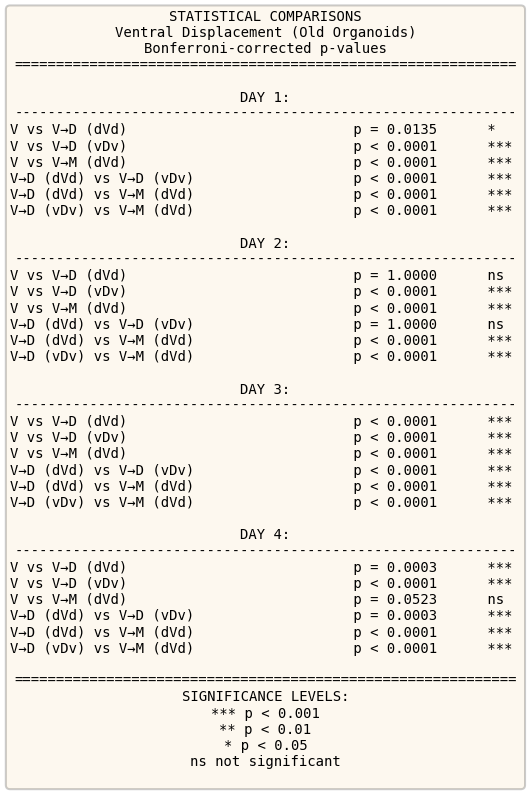


VENTRAL DISPLACEMENT (OLD ORGANOIDS) - STATISTICAL ANALYSIS
Total comparisons performed: 24
Significant comparisons (p < 0.05): 21
Non-significant comparisons: 3

SIGNIFICANCE BY DAY:
----------------------------------------------------------------------
Day 1: 6/6 significant comparisons
Day 2: 4/6 significant comparisons
Day 3: 6/6 significant comparisons
Day 4: 5/6 significant comparisons

SIGNIFICANCE LEVEL BREAKDOWN:
----------------------------------------------------------------------
p < 0.001 : 20 comparisons
p < 0.01  :  0 comparisons
p < 0.05  :  1 comparisons
ns        :  3 comparisons

SAMPLE SIZES BY CONDITION AND DAY:
----------------------------------------------------------------------

Ventral None (V):
  Day 1: n = 47
  Day 2: n = 46
  Day 3: n = 48
  Day 4: n = 47

Ventral -> Dorsal (dVd):
  Day 1: n = 141
  Day 2: n = 144
  Day 3: n = 144
  Day 4: n = 144

Ventral -> Dorsal (vDv):
  Day 1: n = 94
  Day 2: n = 91
  Day 3: n = 96
  Day 4: n = 96

Ventral -> Media (d

In [ ]:
# ======================================================================
# P-VALUE ANALYSIS FOR VENTRAL DISPLACEMENT (OLD ORGANOIDS)
# ======================================================================
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

# ======================================================================
# HELPER FUNCTIONS
# ======================================================================
def remove_outliers(data, threshold=3):
    """Remove outliers using z-score method"""
    if len(data) == 0:
        return data
    z_scores = np.abs((data - np.mean(data)) / np.std(data))
    return data[z_scores < threshold]

def get_significance_stars(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

# ======================================================================
# MAIN ANALYSIS
# ======================================================================
# Prepare all comparisons
all_p_values = []
all_comparisons = []
all_data_dict = {}

# Store data for each condition and day
for cond_name, cond_info in conditions.items():
    all_data_dict[cond_name] = {}
    cols = [col for col in cond_info['columns'] if col in df_old.columns]

    for day_idx, (start, end) in enumerate(days):
        if time_col in df_old.columns:
            data = df_old[(df_old[time_col] >= start) & (df_old[time_col] < end)][cols].values.flatten()
        else:
            data = df_old[cols].values.flatten()

        data = np.abs(data)  # Take absolute values as in your plot
        data = data[~np.isnan(data)]
        data = remove_outliers(data)
        all_data_dict[cond_name][f'day{day_idx+1}'] = data

# Collect p-values for all day/condition pairs
conditions_list = list(conditions.keys())

for day_idx in range(len(days)):
    day_key = f'day{day_idx+1}'

    for condA, condB in combinations(conditions_list, 2):
        dataA = all_data_dict[condA][day_key]
        dataB = all_data_dict[condB][day_key]

        if len(dataA) > 0 and len(dataB) > 0:
            # Use Mann-Whitney U test (non-parametric)
            stat, p = mannwhitneyu(dataA, dataB, alternative='two-sided')
            all_p_values.append(p)
            all_comparisons.append({
                'day': day_idx + 1,
                'condA': condA,
                'condB': condB,
                'p_original': p
            })

# Bonferroni correction
if len(all_p_values) > 0:
    reject, p_corrected, _, _ = multipletests(all_p_values, method='bonferroni')

    # Apply corrected p-values to comparisons
    for i, comp in enumerate(all_comparisons):
        comp['p_corrected'] = p_corrected[i]
        comp['significant'] = reject[i]
        comp['stars'] = get_significance_stars(p_corrected[i])

# ======================================================================
# CREATE P-VALUE LEGEND FIGURE FOR VENTRAL CONDITIONS
# ======================================================================
fig_pval = plt.figure(figsize=(3, 3))
ax_pval = fig_pval.add_subplot(111)

# Remove axes
ax_pval.axis('off')

# Build text content
p_text_lines = []
p_text_lines.append("STATISTICAL COMPARISONS")
p_text_lines.append("Ventral Displacement (Old Organoids)")
p_text_lines.append("Bonferroni-corrected p-values")
p_text_lines.append("=" * 60)
p_text_lines.append("")

# Group comparisons by day
for day_num in range(1, 5):
    day_comps = [c for c in all_comparisons if c['day'] == day_num]
    if day_comps:
        p_text_lines.append(f"DAY {day_num}:")
        p_text_lines.append("-" * 60)

        for comp in day_comps:
            p_corr = comp['p_corrected']
            stars = comp['stars']

            # Format p-value
            if p_corr < 0.0001:
                p_str = "p < 0.0001"
            else:
                p_str = f"p = {p_corr:.4f}"

            # Create abbreviated condition names
            condA_abbr = (comp['condA']
                         .replace('Ventral ', 'V')
                         .replace('->Dorsal', '→D')
                         .replace('-> Dorsal', '→D')
                         .replace('->Media', '→M')
                         .replace('-> Media', '→M')
                         .replace('->', '→')
                         .replace('None', '')
                         .replace(' (V)', ''))

            condB_abbr = (comp['condB']
                         .replace('Ventral ', 'V')
                         .replace('->Dorsal', '→D')
                         .replace('-> Dorsal', '→D')
                         .replace('->Media', '→M')
                         .replace('-> Media', '→M')
                         .replace('->', '→')
                         .replace('None', '')
                         .replace(' (V)', ''))

            # Create formatted line
            comp_label = f"{condA_abbr} vs {condB_abbr}"
            line = f"{comp_label:40s} {p_str:15s} {stars:4s}"
            p_text_lines.append(line)

        p_text_lines.append("")

# Add legend
p_text_lines.append("=" * 60)
p_text_lines.append("SIGNIFICANCE LEVELS:")
p_text_lines.append("*** p < 0.001")
p_text_lines.append("** p < 0.01")
p_text_lines.append("* p < 0.05")
p_text_lines.append("ns not significant")
p_text_lines.append("")

# Join all lines
p_value_text = '\n'.join(p_text_lines)

# Add text to figure with box
props = dict(boxstyle='round', facecolor='wheat', alpha=0.2,
             edgecolor='black', linewidth=1.5)

ax_pval.text(0.5, 0.5, p_value_text,
             transform=ax_pval.transAxes,
             fontsize=10,
             verticalalignment='center',
             horizontalalignment='center',
             fontfamily='monospace',
             bbox=props)

plt.tight_layout()

# Save the figure
plt.savefig('ventral_displacement_old_pvalue_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ======================================================================
# PRINT DETAILED STATISTICAL SUMMARY FOR VENTRAL CONDITIONS
# ======================================================================
print("\n" + "="*70)
print("VENTRAL DISPLACEMENT (OLD ORGANOIDS) - STATISTICAL ANALYSIS")
print("="*70)
print(f"Total comparisons performed: {len(all_p_values)}")
print(f"Significant comparisons (p < 0.05): {sum(reject)}")
print(f"Non-significant comparisons: {len(all_p_values) - sum(reject)}")

# Summary by day
print("\nSIGNIFICANCE BY DAY:")
print("-" * 70)
for day_num in range(1, 5):
    day_comps = [c for c in all_comparisons if c['day'] == day_num]
    if day_comps:
        day_significant = sum(1 for c in day_comps if c['significant'])
        print(f"Day {day_num}: {day_significant}/{len(day_comps)} significant comparisons")

# Summary by significance level
print("\nSIGNIFICANCE LEVEL BREAKDOWN:")
print("-" * 70)
significance_levels = {
    'p < 0.001': 0,
    'p < 0.01': 0,
    'p < 0.05': 0,
    'ns': 0
}

for comp in all_comparisons:
    p_val = comp['p_corrected']
    if p_val < 0.001:
        significance_levels['p < 0.001'] += 1
    elif p_val < 0.01:
        significance_levels['p < 0.01'] += 1
    elif p_val < 0.05:
        significance_levels['p < 0.05'] += 1
    else:
        significance_levels['ns'] += 1

for level, count in significance_levels.items():
    print(f"{level:10s}: {count:2d} comparisons")

# Sample sizes
print("\nSAMPLE SIZES BY CONDITION AND DAY:")
print("-" * 70)
for cond_name in conditions_list:
    print(f"\n{cond_name}:")
    for day_num in range(1, 5):
        day_key = f'day{day_num}'
        n = len(all_data_dict[cond_name][day_key])
        print(f"  Day {day_num}: n = {n}")

# Most significant comparisons
print("\nMOST SIGNIFICANT COMPARISONS:")
print("-" * 70)
significant_comps = [c for c in all_comparisons if c['significant']]
significant_comps.sort(key=lambda x: x['p_corrected'])

for i, comp in enumerate(significant_comps[:5]):  # Top 5 most significant
    condA_abbr = (comp['condA']
                 .replace('Ventral ', 'V')
                 .replace('->Dorsal', '→D')
                 .replace('-> Dorsal', '→D')
                 .replace('->Media', '→M')
                 .replace('-> Media', '→M')
                 .replace('->', '→')
                 .replace('None', '')
                 .replace(' (V)', ''))

    condB_abbr = (comp['condB']
                 .replace('Ventral ', 'V')
                 .replace('->Dorsal', '→D')
                 .replace('-> Dorsal', '→D')
                 .replace('->Media', '→M')
                 .replace('-> Media', '→M')
                 .replace('->', '→')
                 .replace('None', '')
                 .replace(' (V)', ''))

    print(f"{i+1:2d}. Day {comp['day']}: {condA_abbr:25s} vs {condB_abbr:25s} | p = {comp['p_corrected']:.6f}")

print("="*70)
print("P-value analysis saved as: ventral_displacement_old_pvalue_analysis.png")




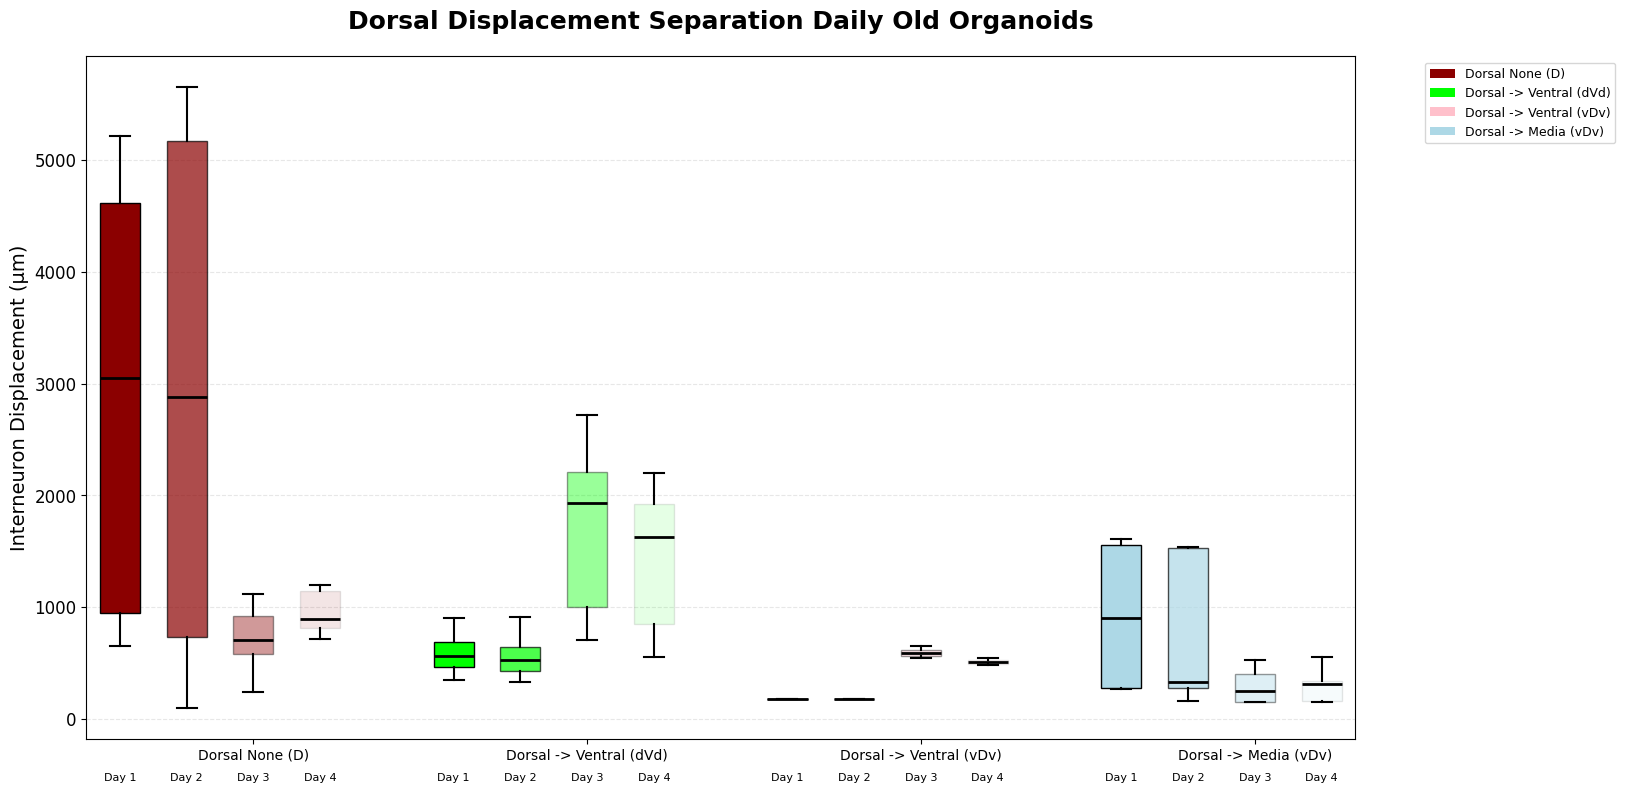

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
from scipy import stats
import itertools


# ======================
# STANDARDIZED PLOT CONFIG
# ======================
PLOT_CONFIG = {
    'figsize': (16, 8),
    'title_fontsize': 18,
    'title_weight': 'bold',
    'title_pad': 20,
    'label_fontsize': 14,
    'tick_fontsize': 12,
    'xtick_fontsize': 10,
    'legend_fontsize': 9,
    'box_width': 0.6,
    'line_width': 1.5,
    'median_width': 2,
    'alpha': 0.7,
    'grid_alpha': 0.3
}

# Load the Excel files
df_young = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')
df_old_ventral = pd.read_excel('6 Days Average Ventral Only (3).xlsx', sheet_name='6 Days Ventral Only-Average')
df_old_dvd = pd.read_excel('6 Days dVd average (2).xlsx', sheet_name='6 Days dVd-Average')
df_old_vdv = pd.read_excel('6 days vDv average.xlsx', sheet_name='6 days vDV - Average')

# Clean column names by removing extra spaces
df_young.columns = [col.strip() for col in df_young.columns]
df_old_ventral.columns = [col.strip() for col in df_old_ventral.columns]
df_old_dvd.columns = [col.strip() for col in df_old_dvd.columns]
df_old_vdv.columns = [col.strip() for col in df_old_vdv.columns]

# Combine old organoid data - handle duplicate column names
df_old = pd.concat([df_old_ventral, df_old_dvd, df_old_vdv], axis=1)

# Check for duplicate column names
duplicate_columns = df_old.columns[df_old.columns.duplicated()].tolist()
if duplicate_columns:
    # Keep only the first occurrence of each column
    df_old = df_old.loc[:, ~df_old.columns.duplicated()]

# Define conditions based on the actual column names from your output
conditions = {
    'Dorsal None (D)': {
        'columns': [
            'Avergae',
            'Average.1',
            'Average.2',
            'Average.3',
            'Average.4'
        ],
        'color': 'darkred'
    },
    'Dorsal -> Ventral (dVd)': {
        'columns': [
            'Dorsal->Ventral',
            'Dorsal->Ventral.1',
            'Dorsal->Ventral.2',
            'Dorsal->Ventral.3',
            'Dorsal->Ventral.4'
        ],
        'color': 'lime'
    },
    'Dorsal -> Ventral (vDv)': {
        'columns': [
            'Dorsal-> Ventral',
            'Dorsal-> Ventral.1',
            'Dorsal-> Ventral.2',
            'Dorsal-> Ventral.3',
            'Dorsal-> Ventral.4'
        ],
        'color': 'pink'
    },
    'Dorsal -> Media (vDv)': {
        'columns': [
            'Dorsal towards Media',
            'Dorsal towards Media.1',
            'Dorsal towards Media.2',
            'Dorsal towards Media.3',
            'Dorsal towards Media.4'
        ],
        'color': 'lightblue'
    }
}

# ======================
# DEFINE TIME PERIODS
# ======================
days = [(0, 24), (24, 48), (48, 72), (72, 96)]
day_labels = ['Day 1', 'Day 2', 'Day 3', 'Day 4']

# ======================
# HELPER FUNCTIONS
# ======================
def remove_outliers(data):
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    return data[(data >= q1 - 1.5*iqr) & (data <= q3 + 1.5*iqr)]

def get_significance_stars(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

def perform_statistical_test(data1, data2):
    if len(data1) == 0 or len(data2) == 0:
        return np.nan
    if len(data1) > 7:
        _, p_normal1 = stats.normaltest(data1)
    else:
        p_normal1 = 0.05
    if len(data2) > 7:
        _, p_normal2 = stats.normaltest(data2)
    else:
        p_normal2 = 0.05
    if p_normal1 < 0.05 or p_normal2 < 0.05:
        try:
            _, p_value = stats.mannwhitneyu(data1, data2)
        except:
            p_value = 1.0
    else:
        _, p_value = stats.ttest_ind(data1, data2)
    return p_value

# ======================
# EXTRACT DATA FOR PLOTTING
# ======================
all_data = {}
time_col = 'Time (hr)'

for cond_name, cond_info in conditions.items():
    cols = [col for col in cond_info['columns'] if col in df_old.columns]
    if not cols:
        continue

    day_data_list = []
    for start, end in days:
        if time_col in df_old.columns:
            data = np.abs(df_old[(df_old[time_col] >= start) & (df_old[time_col] < end)][cols].values.flatten())
        else:
            data = np.abs(df_old[cols].values.flatten())
        data = remove_outliers(data[~np.isnan(data)])
        day_data_list.append(data)
    all_data[cond_name] = day_data_list

# ======================
# PLOT
# ======================
plt.figure(figsize=PLOT_CONFIG['figsize'])

for i, (cond_name, cond_info) in enumerate(conditions.items()):
    positions = [i*5 + j for j in range(len(days))]
    base_color = cond_info['color']
    for j, data in enumerate(all_data[cond_name]):
        if len(data) > 0:
            plt.boxplot(data, positions=[positions[j]], widths=PLOT_CONFIG['box_width'], patch_artist=True,
                        boxprops=dict(facecolor=base_color, alpha=[1.0,0.7,0.4,0.1][j], edgecolor='black'),
                        medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                        whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                        capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                        showfliers=False)

# Customize plot with PLOT_CONFIG
plt.title('Dorsal Displacement Separation Daily Old Organoids',
          fontsize=PLOT_CONFIG['title_fontsize'], fontweight=PLOT_CONFIG['title_weight'], pad=PLOT_CONFIG['title_pad'])
plt.ylabel('Interneuron Displacement (μm)', fontsize=PLOT_CONFIG['label_fontsize'])

xticks = [i*5 + 2 for i in range(len(conditions))]
plt.xticks(xticks, conditions.keys(), rotation=0, ha='center', fontsize=PLOT_CONFIG['xtick_fontsize'])
plt.yticks(fontsize=PLOT_CONFIG['tick_fontsize'])

y_min, y_max = plt.ylim()
for i in range(len(conditions)):
    for j, label in enumerate(day_labels):
        plt.text(i*5 + j, y_min - 0.05*(y_max-y_min), label, ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2)

legend_elements = [Patch(facecolor=cond_info['color'], label=cond_name)
                   for cond_name, cond_info in conditions.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=PLOT_CONFIG['legend_fontsize'])

plt.grid(True, axis='y', linestyle='--', alpha=PLOT_CONFIG['grid_alpha'])
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()


p-value comparisons

/tmp/ipython-input-359847737.py:173: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


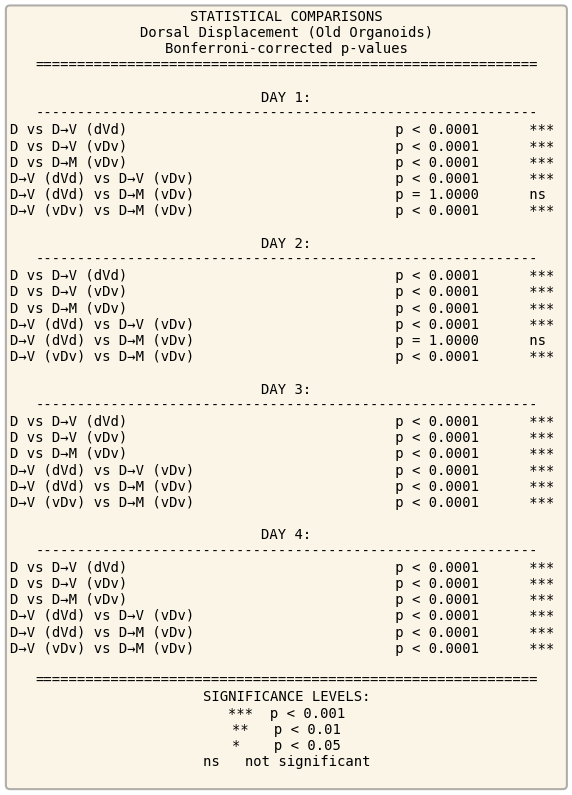


DORSAL DISPLACEMENT (OLD ORGANOIDS) - STATISTICAL ANALYSIS
Total comparisons performed: 24

SIGNIFICANCE BY DAY:
----------------------------------------------------------------------
Day 1: 5/6 significant comparisons
Day 2: 5/6 significant comparisons
Day 3: 6/6 significant comparisons
Day 4: 6/6 significant comparisons

SIGNIFICANCE LEVEL BREAKDOWN:
----------------------------------------------------------------------
p < 0.001 : 22 comparisons
p < 0.01  :  0 comparisons
p < 0.05  :  0 comparisons
ns        :  2 comparisons

SAMPLE SIZES BY CONDITION AND DAY:
----------------------------------------------------------------------

Dorsal None (D):
  Day 1: n = 141
  Day 2: n = 144
  Day 3: n = 144
  Day 4: n = 144

Dorsal -> Ventral (dVd):
  Day 1: n = 235
  Day 2: n = 225
  Day 3: n = 240
  Day 4: n = 240

Dorsal -> Ventral (vDv):
  Day 1: n = 47
  Day 2: n = 48
  Day 3: n = 48
  Day 4: n = 48

Dorsal -> Media (vDv):
  Day 1: n = 94
  Day 2: n = 96
  Day 3: n = 96
  Day 4: n = 96


In [ ]:
# ======================================================================
# P-VALUE ANALYSIS FOR DORSAL DISPLACEMENT (OLD ORGANOIDS)
# ======================================================================
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

# ======================================================================
# HELPER FUNCTIONS
# ======================================================================
def remove_outliers(data, threshold=3):
    """Remove outliers using z-score method"""
    if len(data) == 0:
        return data
    z_scores = np.abs((data - np.mean(data)) / np.std(data))
    return data[z_scores < threshold]

def get_significance_stars(p_value):
    """Convert p-value to significance stars"""
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

# ======================================================================
# MAIN ANALYSIS
# ======================================================================
# Prepare all comparisons
all_p_values = []
all_comparisons = []
all_data_dict = {}

# Store data for each condition and day
for cond_name, cond_info in conditions.items():
    all_data_dict[cond_name] = {}
    cols = [col for col in cond_info['columns'] if col in df_old.columns]

    for day_idx, (start, end) in enumerate(days):
        if time_col in df_old.columns:
            data = df_old[(df_old[time_col] >= start) & (df_old[time_col] < end)][cols].values.flatten()
        else:
            data = df_old[cols].values.flatten()

        data = np.abs(data)  # Take absolute values as in your plot
        data = data[~np.isnan(data)]
        data = remove_outliers(data)
        all_data_dict[cond_name][f'day{day_idx+1}'] = data

# Collect p-values for all day/condition pairs
conditions_list = list(conditions.keys())

for day_idx in range(len(days)):
    day_key = f'day{day_idx+1}'

    for condA, condB in combinations(conditions_list, 2):
        dataA = all_data_dict[condA][day_key]
        dataB = all_data_dict[condB][day_key]

        if len(dataA) > 0 and len(dataB) > 0:
            # Use Mann-Whitney U test (non-parametric)
            stat, p = mannwhitneyu(dataA, dataB, alternative='two-sided')
            all_p_values.append(p)
            all_comparisons.append({
                'day': day_idx + 1,
                'condA': condA,
                'condB': condB,
                'p_original': p
            })

# Bonferroni correction
if len(all_p_values) > 0:
    reject, p_corrected, _, _ = multipletests(all_p_values, method='bonferroni')

    # Apply corrected p-values to comparisons
    for i, comp in enumerate(all_comparisons):
        comp['p_corrected'] = p_corrected[i]
        comp['significant'] = reject[i]
        comp['stars'] = get_significance_stars(p_corrected[i])

# ======================================================================
# CREATE P-VALUE LEGEND FIGURE FOR DORSAL CONDITIONS
# ======================================================================
fig_pval = plt.figure(figsize=(3, 3))
ax_pval = fig_pval.add_subplot(111)

# Remove axes
ax_pval.axis('off')

# Build text content
p_text_lines = []
p_text_lines.append("STATISTICAL COMPARISONS")
p_text_lines.append("Dorsal Displacement (Old Organoids)")
p_text_lines.append("Bonferroni-corrected p-values")
p_text_lines.append("=" * 60)
p_text_lines.append("")

# Group comparisons by day
for day_num in range(1, 5):
    day_comps = [c for c in all_comparisons if c['day'] == day_num]

    if day_comps:
        p_text_lines.append(f"DAY {day_num}:")
        p_text_lines.append("-" * 60)

        for comp in day_comps:
            p_corr = comp['p_corrected']
            stars = comp['stars']

            # Format p-value
            if p_corr < 0.0001:
                p_str = "p < 0.0001"
            else:
                p_str = f"p = {p_corr:.4f}"

            # Create abbreviated condition names - apply all replacements in sequence
            condA_abbr = (comp['condA']
                         .replace('Dorsal ', 'D')
                         .replace('->Ventral', '→V')
                         .replace('-> Ventral', '→V')
                         .replace('->Media', '→M')
                         .replace('-> Media', '→M')
                         .replace('->', '→')
                         .replace('None', '')
                         .replace(' (D)', ''))

            condB_abbr = (comp['condB']
                         .replace('Dorsal ', 'D')
                         .replace('->Ventral', '→V')
                         .replace('-> Ventral', '→V')
                         .replace('->Media', '→M')
                         .replace('-> Media', '→M')
                         .replace('->', '→')
                         .replace('None', '')
                         .replace(' (D)', ''))

            # Create formatted line
            comp_label = f"{condA_abbr} vs {condB_abbr}"
            line = f"{comp_label:45s} {p_str:15s} {stars:4s}"
            p_text_lines.append(line)

        p_text_lines.append("")

# Add legend
p_text_lines.append("=" * 60)
p_text_lines.append("SIGNIFICANCE LEVELS:")
p_text_lines.append("***  p < 0.001")
p_text_lines.append("**   p < 0.01")
p_text_lines.append("*    p < 0.05")
p_text_lines.append("ns   not significant")
p_text_lines.append("")

# Join all lines
p_value_text = '\n'.join(p_text_lines)

# Add text to figure with box
props = dict(boxstyle='round', facecolor='wheat', alpha=0.3,
             edgecolor='black', linewidth=1.5)

ax_pval.text(0.5, 0.5, p_value_text,
            transform=ax_pval.transAxes,
            fontsize=10,
            verticalalignment='center',
            horizontalalignment='center',
            fontfamily='monospace',
            bbox=props)

plt.tight_layout()

# Save the figure
plt.savefig('dorsal_displacement_old_pvalue_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ======================================================================
# PRINT DETAILED STATISTICAL SUMMARY FOR DORSAL CONDITIONS
# ======================================================================
print("\n" + "="*70)
print("DORSAL DISPLACEMENT (OLD ORGANOIDS) - STATISTICAL ANALYSIS")
print("="*70)
print(f"Total comparisons performed: {len(all_p_values)}")

# Summary by day
print("\nSIGNIFICANCE BY DAY:")
print("-" * 70)
for day_num in range(1, 5):
    day_comps = [c for c in all_comparisons if c['day'] == day_num]
    if day_comps:
        day_significant = sum(1 for c in day_comps if c['significant'])
        print(f"Day {day_num}: {day_significant}/{len(day_comps)} significant comparisons")

# Summary by significance level
print("\nSIGNIFICANCE LEVEL BREAKDOWN:")
print("-" * 70)
significance_levels = {
    'p < 0.001': 0,
    'p < 0.01': 0,
    'p < 0.05': 0,
    'ns': 0
}

for comp in all_comparisons:
    p_val = comp['p_corrected']
    if p_val < 0.001:
        significance_levels['p < 0.001'] += 1
    elif p_val < 0.01:
        significance_levels['p < 0.01'] += 1
    elif p_val < 0.05:
        significance_levels['p < 0.05'] += 1
    else:
        significance_levels['ns'] += 1

for level, count in significance_levels.items():
    print(f"{level:10s}: {count:2d} comparisons")

# Sample sizes
print("\nSAMPLE SIZES BY CONDITION AND DAY:")
print("-" * 70)
for cond_name in conditions_list:
    print(f"\n{cond_name}:")
    for day_num in range(1, 5):
        day_key = f'day{day_num}'
        n = len(all_data_dict[cond_name][day_key])
        print(f"  Day {day_num}: n = {n}")

# Most significant comparisons
print("\nMOST SIGNIFICANT COMPARISONS:")
print("-" * 70)
significant_comps = [c for c in all_comparisons if c['significant']]
significant_comps.sort(key=lambda x: x['p_corrected'])

for i, comp in enumerate(significant_comps[:5]):  # Top 5 most significant
    condA_abbr = (comp['condA']
                 .replace('Dorsal ', 'D')
                 .replace('->Ventral', '→V')
                 .replace('-> Ventral', '→V')
                 .replace('->Media', '→M')
                 .replace('-> Media', '→M')
                 .replace('->', '→')
                 .replace('None', '')
                 .replace(' (D)', ''))

    condB_abbr = (comp['condB']
                 .replace('Dorsal ', 'D')
                 .replace('->Ventral', '→V')
                 .replace('-> Ventral', '→V')
                 .replace('->Media', '→M')
                 .replace('-> Media', '→M')
                 .replace('->', '→')
                 .replace('None', '')
                 .replace(' (D)', ''))

    print(f"{i+1:2d}. Day {comp['day']}: {condA_abbr:25s} vs {condB_abbr:25s} | p = {comp['p_corrected']:.6f}")

print("="*70)
print("P-value analysis saved as: dorsal_displacement_old_pvalue_analysis.png")

##Velocity Old Ogranoids

Processing Ventral Only (V) with columns: ['Velocity 1V', 'Velocity 2V', 'Velocity 3V', 'Velocity 4V']
Ventral Only (V) - Day 1 data points: 188
Ventral Only (V) - Day 2 data points: 192
Ventral Only (V) - Day 3 data points: 192
Ventral Only (V) - Day 4 data points: 192
Processing Ventral -> Dorsal (dVd) with columns: ['Velocity Dorsal->Ventral', 'Velocity Dorsal->Ventral.1', 'Velocity Dorsal->Ventral.2', 'Velocity Dorsal->Ventral.3', 'Velocity Dorsal->Ventral.4']
Ventral -> Dorsal (dVd) - Day 1 data points: 235
Ventral -> Dorsal (dVd) - Day 2 data points: 240
Ventral -> Dorsal (dVd) - Day 3 data points: 240
Ventral -> Dorsal (dVd) - Day 4 data points: 240
Processing Ventral -> Dorsal (vDv) with columns: ['Velocity Ventral->Dorsal', 'Velocity Ventral->Dorsal.1', 'Velocity Ventral->Dorsal.2', 'Velocity Ventral->Dorsal.3', 'Velocity Ventral->Dorsal.4']
Ventral -> Dorsal (vDv) - Day 1 data points: 235
Ventral -> Dorsal (vDv) - Day 2 data points: 240
Ventral -> Dorsal (vDv) - Day 3 data po

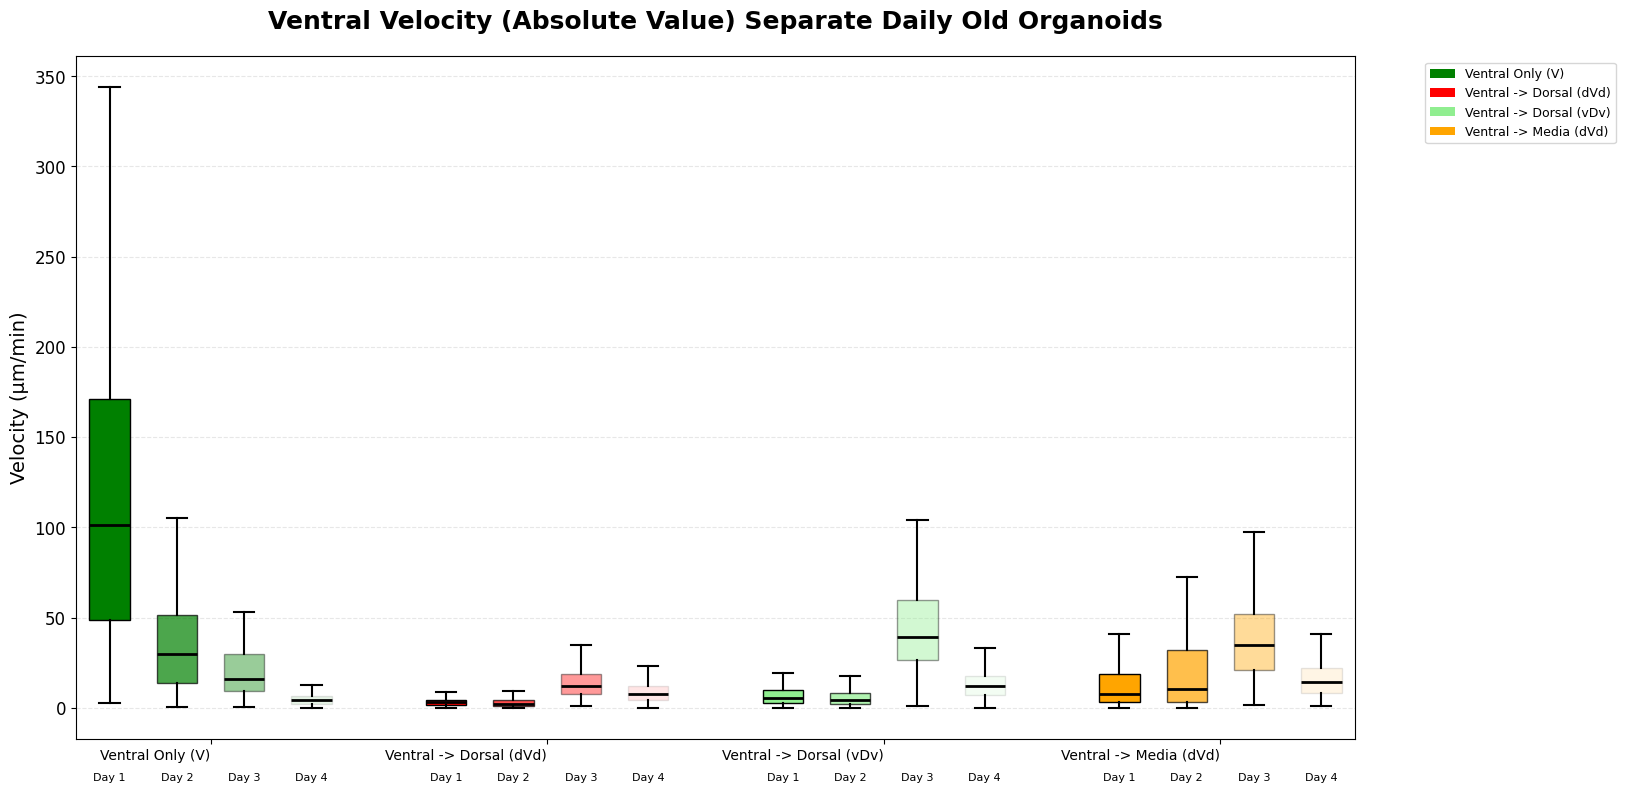


DORSAL VELOCITY ANALYSIS COMPLETE


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
from scipy import stats
import itertools

# Load the Excel files
df_young = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')
df_old_ventral = pd.read_excel('6 Days Average Ventral Only (3).xlsx', sheet_name='6 Days Ventral Only-Average')
df_old_dvd = pd.read_excel('6 Days dVd average (2).xlsx', sheet_name='6 Days dVd-Average')
df_old_vdv = pd.read_excel('6 days vDv average.xlsx', sheet_name='6 days vDV - Average')

# Clean column names by removing extra spaces
df_young.columns = [col.strip() for col in df_young.columns]
df_old_ventral.columns = [col.strip() for col in df_old_ventral.columns]
df_old_dvd.columns = [col.strip() for col in df_old_dvd.columns]
df_old_vdv.columns = [col.strip() for col in df_old_vdv.columns]

# Combine old organoid data - handle duplicate column names
df_old = pd.concat([df_old_ventral, df_old_dvd, df_old_vdv], axis=1)

# Check for duplicate column names
duplicate_columns = df_old.columns[df_old.columns.duplicated()].tolist()
if duplicate_columns:
    # Keep only the first occurrence of each column
    df_old = df_old.loc[:, ~df_old.columns.duplicated()]



# Define conditions based on the actual column names from your output
conditions = {
    # 1. Ventral only (V)
    'Ventral Only (V)': {
        'columns': [
            'Velocity 1V',
            'Velocity 2V',
            'Velocity 3V',
            'Velocity 4V'
        ],
        'color': 'green'
    },
    # 2. Ventral -> Dorsal (dVd)
    'Ventral -> Dorsal (dVd)': {
        'columns': [
            'Velocity Dorsal->Ventral',
            'Velocity Dorsal->Ventral.1',
            'Velocity Dorsal->Ventral.2',
            'Velocity Dorsal->Ventral.3',
            'Velocity Dorsal->Ventral.4'
        ],
        'color': 'red'
    },
    # 3. Dorsal -> Ventral (vDv)
    'Ventral -> Dorsal (vDv)': {
        'columns': [
            'Velocity Ventral->Dorsal',
            'Velocity Ventral->Dorsal.1',
            'Velocity Ventral->Dorsal.2',
            'Velocity Ventral->Dorsal.3',
            'Velocity Ventral->Dorsal.4'
        ],
        'color': 'lightgreen'
    },
    # 4. Ventral -> Media (dVd)
    'Ventral -> Media (dVd)': {
        'columns': [
            'Velocity Ventral towards media',
            'Velocity Ventral towards media.1',
            'Velocity Ventral towards media.2',
            'Velocity Ventral towards media.3',
            'Velocity Ventral towards media.4'
        ],
        'color': 'orange'
    },
}

# Define day ranges
day1 = [0, 24]    # Day 1: 0-24 hours
day2 = [24, 48]   # Day 2: 24-48 hours
day3 = [48, 72]   # Day 3: 48-72 hours
day4 = [72, 96]   # Day 4: 72-96 hours

# Function to remove outliers using IQR method
def remove_outliers(data):
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Function to convert p-value to significance stars
def get_significance_stars(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

# Function to perform statistical test between two datasets
def perform_statistical_test(data1, data2):
    if len(data1) == 0 or len(data2) == 0:
        return np.nan

    # Check normality
    if len(data1) > 7:  # normaltest requires at least 8 samples
        _, p_normal1 = stats.normaltest(data1)
    else:
        p_normal1 = 0.05  # Assume non-normal for small samples

    if len(data2) > 7:
        _, p_normal2 = stats.normaltest(data2)
    else:
        p_normal2 = 0.05  # Assume non-normal for small samples

    # Use appropriate test based on normality
    if p_normal1 < 0.05 or p_normal2 < 0.05:
        # Non-parametric test
        try:
            _, p_value = stats.mannwhitneyu(data1, data2)
        except:
            p_value = 1.0
    else:
        # Parametric test
        _, p_value = stats.ttest_ind(data1, data2)

    return p_value

# Store all data for statistical testing
all_data = {}
condition_names = list(conditions.keys())

# Create figure with standardized dimensions
fig = plt.figure(figsize=PLOT_CONFIG['figsize'])

# For each condition, extract data for each day and create boxplots
for i, (cond_name, cond_info) in enumerate(conditions.items()):
    # Get all valid columns for this condition that exist in the dataframe
    cols = [col for col in cond_info['columns'] if col in df_old.columns]

    if not cols:  # Skip if no valid columns found
        print(f"Warning: No valid columns found for {cond_name}")
        continue

    print(f"Processing {cond_name} with columns: {cols}")

    # Extract data for each day with safe filtering
    # Use the first time column (we removed duplicates)
    time_col = 'Time (hr)'
    if time_col in df_old.columns:
        # Make sure we're using the correct time column (first occurrence)
        day1_data = np.abs(df_old[(df_old[time_col] >= day1[0]) & (df_old[time_col] < day1[1])][cols].values.flatten())
        day2_data = np.abs(df_old[(df_old[time_col] >= day2[0]) & (df_old[time_col] < day2[1])][cols].values.flatten())
        day3_data = np.abs(df_old[(df_old[time_col] >= day3[0]) & (df_old[time_col] < day3[1])][cols].values.flatten())
        day4_data = np.abs(df_old[(df_old[time_col] >= day4[0]) & (df_old[time_col] < day4[1])][cols].values.flatten())

        print(f"{cond_name} - Day 1 data points: {len(day1_data)}")
        print(f"{cond_name} - Day 2 data points: {len(day2_data)}")
        print(f"{cond_name} - Day 3 data points: {len(day3_data)}")
        print(f"{cond_name} - Day 4 data points: {len(day4_data)}")
    else:
        print("Warning: 'Time (hr)' column not found. Using all data without time filtering.")
        # Use all data if time column doesn't exist
        day1_data = np.abs(df_old[cols].values.flatten())
        day2_data = np.array([])
        day3_data = np.array([])
        day4_data = np.array([])

    # Remove NaN values and outliers
    day1_data = remove_outliers(day1_data[~np.isnan(day1_data)])
    day2_data = remove_outliers(day2_data[~np.isnan(day2_data)])
    day3_data = remove_outliers(day3_data[~np.isnan(day3_data)])
    day4_data = remove_outliers(day4_data[~np.isnan(day4_data)])

    # Store data for statistical testing
    all_data[cond_name] = {
        'day1': day1_data,
        'day2': day2_data,
        'day3': day3_data,
        'day4': day4_data
    }

    # Create positions for boxplots (grouped by condition)
    positions = [i*5, i*5+1, i*5+2, i*5+3]  # Increased spacing to 5

    # Get the color for this condition
    base_color = cond_info['color']

    # Create boxplots with different transparency for each day - standardized parameters
    if len(day1_data) > 0:
        plt.boxplot(day1_data, positions=[positions[0]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=1.0, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

    if len(day2_data) > 0:
        plt.boxplot(day2_data, positions=[positions[1]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=0.7, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

    if len(day3_data) > 0:
        plt.boxplot(day3_data, positions=[positions[2]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=0.4, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

    if len(day4_data) > 0:
        plt.boxplot(day4_data, positions=[positions[3]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=0.1, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

# Calculate and print p-value comparisons
print("\n" + "=" * 80)
print("P-VALUE ANALYSIS: COMPARISON BETWEEN DORSAL VELOCITY CONDITIONS WITHIN EACH DAY")
print("=" * 80)

days = ['day1', 'day2', 'day3', 'day4']

for day in days:
    print(f"\n{day.upper()} (Hours {eval(day)[0]}-{eval(day)[1]}):")
    print("-" * 40)

    # Compare all pairs of conditions
    for i, j in itertools.combinations(range(len(condition_names)), 2):
        cond1 = condition_names[i]
        cond2 = condition_names[j]

        data1 = all_data[cond1][day]
        data2 = all_data[cond2][day]

        p_value = perform_statistical_test(data1, data2)

        if not np.isnan(p_value):
            star = get_significance_stars(p_value)
            print(f"{cond1} vs {cond2}: p = {p_value:.4f} {star}")
        else:
            print(f"{cond1} vs {cond2}: Insufficient data")

# Customize the plot with standardized fonts
plt.title('Ventral Velocity (Absolute Value) Separate Daily Old Organoids',
          fontsize=PLOT_CONFIG['title_fontsize'],
          fontweight=PLOT_CONFIG['title_weight'],
          pad=PLOT_CONFIG['title_pad'])
plt.ylabel('Velocity (μm/min)', fontsize=PLOT_CONFIG['label_fontsize'])

# Set x-ticks and labels with standardized font size
xticks = [i*5+1.5 for i in range(len(conditions))]  # Adjusted for new spacing
plt.xticks(xticks, conditions.keys(), rotation=0, ha='right',
           fontsize=PLOT_CONFIG['xtick_fontsize'])
plt.yticks(fontsize=PLOT_CONFIG['tick_fontsize'])

# Add day indicators below x-axis with standardized font size
y_min, y_max = plt.ylim()
for i, cond in enumerate(conditions):
    plt.text(i*5+0, y_min - 0.05*(y_max-y_min), 'Day 1',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')
    plt.text(i*5+1, y_min - 0.05*(y_max-y_min), 'Day 2',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')
    plt.text(i*5+2, y_min - 0.05*(y_max-y_min), 'Day 3',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')
    plt.text(i*5+3, y_min - 0.05*(y_max-y_min), 'Day 4',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')

# Create legend for conditions using their defined colors with standardized font size
legend_elements = [Patch(facecolor=cond_info['color'], label=cond_name)
                  for cond_name, cond_info in conditions.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=PLOT_CONFIG['legend_fontsize'])

# Add grid and adjust layout with standardized alpha
plt.grid(True, axis='y', linestyle='--', alpha=PLOT_CONFIG['grid_alpha'])
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Consistent margin for legend

plt.show()

# Optional: Save with standardized DPI
# plt.savefig('dorsal_daily_velocity_comparison.png', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')

print("\n" + "=" * 80)
print("DORSAL VELOCITY ANALYSIS COMPLETE")
print("=" * 80)

p-value comparison

/tmp/ipython-input-247120934.py:101: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


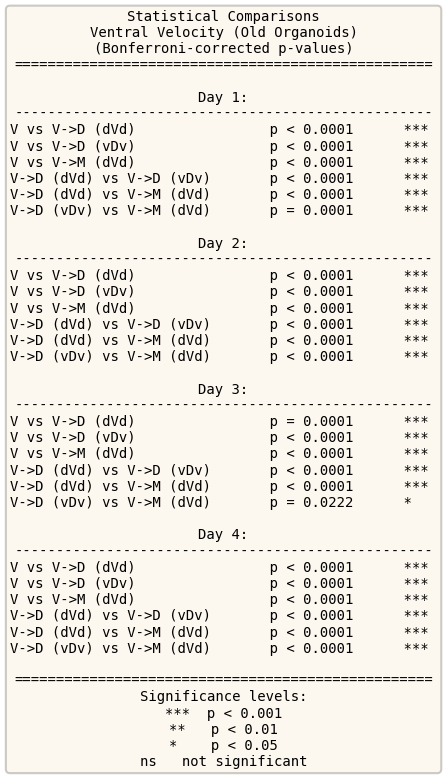


VENTRAL DISPLACEMENT (YOUNG ORGANOIDS) STATISTICAL SUMMARY
Total comparisons: 24
Significant comparisons (p < 0.001): 23
Significant comparisons (p < 0.01): 0
Significant comparisons (p < 0.05): 1

By Day:
  Day 1: 6/6 significant
  Day 2: 6/6 significant
  Day 3: 6/6 significant
  Day 4: 6/6 significant
Figure saved as: ventral_displacement_young_pvalue_legend_6x6.png


In [ ]:
# ======================================================================
# CREATE SEPARATE 6x6 P-VALUE LEGEND FIGURE - VENTRAL DISPLACEMENT (YOUNG)
# ======================================================================
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

# Your p-value data organized
pvalue_data = {
    'Day 1': [
        ('V vs V->D (dVd)', 0.0000, '***'),
        ('V vs V->D (vDv)', 0.0000, '***'),
        ('V vs V->M (dVd)', 0.0000, '***'),
        ('V->D (dVd) vs V->D (vDv)', 0.0000, '***'),
        ('V->D (dVd) vs V->M (dVd)', 0.0000, '***'),
        ('V->D (vDv) vs V->M (dVd)', 0.0001, '***')
    ],
    'Day 2': [
        ('V vs V->D (dVd)', 0.0000, '***'),
        ('V vs V->D (vDv)', 0.0000, '***'),
        ('V vs V->M (dVd)', 0.0000, '***'),
        ('V->D (dVd) vs V->D (vDv)', 0.0000, '***'),
        ('V->D (dVd) vs V->M (dVd)', 0.0000, '***'),
        ('V->D (vDv) vs V->M (dVd)', 0.0000, '***')
    ],
    'Day 3': [
        ('V vs V->D (dVd)', 0.0001, '***'),
        ('V vs V->D (vDv)', 0.0000, '***'),
        ('V vs V->M (dVd)', 0.0000, '***'),
        ('V->D (dVd) vs V->D (vDv)', 0.0000, '***'),
        ('V->D (dVd) vs V->M (dVd)', 0.0000, '***'),
        ('V->D (vDv) vs V->M (dVd)', 0.0222, '*')
    ],
    'Day 4': [
        ('V vs V->D (dVd)', 0.0000, '***'),
        ('V vs V->D (vDv)', 0.0000, '***'),
        ('V vs V->M (dVd)', 0.0000, '***'),
        ('V->D (dVd) vs V->D (vDv)', 0.0000, '***'),
        ('V->D (dVd) vs V->M (dVd)', 0.0000, '***'),
        ('V->D (vDv) vs V->M (dVd)', 0.0000, '***')
    ]
}

# Create 6x6 figure for p-values
fig_pval = plt.figure(figsize=(3, 3))
ax_pval = fig_pval.add_subplot(111)

# Remove axes
ax_pval.axis('off')

# Build text content
p_text_lines = []
p_text_lines.append("Statistical Comparisons")
p_text_lines.append("Ventral Velocity (Old Organoids)")
p_text_lines.append("(Bonferroni-corrected p-values)")
p_text_lines.append("=" * 50)
p_text_lines.append("")

for day_num, (day, comparisons) in enumerate(pvalue_data.items(), 1):
    p_text_lines.append(f"{day}:")
    p_text_lines.append("-" * 50)

    for comp, pval, stars in comparisons:
        # Format p-value
        if pval < 0.0001:
            p_str = "p < 0.0001"
        else:
            p_str = f"p = {pval:.4f}"

        # Create formatted line
        line = f"{comp:30s} {p_str:15s} {stars:4s}"
        p_text_lines.append(line)

    p_text_lines.append("")

# Add legend
p_text_lines.append("=" * 50)
p_text_lines.append("Significance levels:")
p_text_lines.append("***  p < 0.001")
p_text_lines.append("**   p < 0.01")
p_text_lines.append("*    p < 0.05")
p_text_lines.append("ns   not significant")

# Join all lines
p_value_text = '\n'.join(p_text_lines)

# Add text to figure with box
props = dict(boxstyle='round', facecolor='wheat', alpha=0.2,
             edgecolor='black', linewidth=1.5)

ax_pval.text(0.5, 0.5, p_value_text,
            transform=ax_pval.transAxes,
            fontsize=10,
            verticalalignment='center',
            horizontalalignment='center',
            fontfamily='monospace',
            bbox=props)

plt.tight_layout()

# Save the figure
plt.savefig('ventral_displacement_young_pvalue_legend_6x6.png', dpi=300, bbox_inches='tight')
plt.show()

# Display summary statistics
print("\n" + "="*60)
print("VENTRAL DISPLACEMENT (YOUNG ORGANOIDS) STATISTICAL SUMMARY")
print("="*60)

total_comparisons = sum(len(comparisons) for comparisons in pvalue_data.values())
print(f"Total comparisons: {total_comparisons}")

# Count significant comparisons
significant_counts = {0.001: 0, 0.01: 0, 0.05: 0}
for day, comparisons in pvalue_data.items():
    for comp, pval, stars in comparisons:
        if pval < 0.001:
            significant_counts[0.001] += 1
        elif pval < 0.01:
            significant_counts[0.01] += 1
        elif pval < 0.05:
            significant_counts[0.05] += 1

print(f"Significant comparisons (p < 0.001): {significant_counts[0.001]}")
print(f"Significant comparisons (p < 0.01): {significant_counts[0.01]}")
print(f"Significant comparisons (p < 0.05): {significant_counts[0.05]}")

print("\nBy Day:")
for day, comparisons in pvalue_data.items():
    day_significant = sum(1 for comp, pval, stars in comparisons if pval < 0.05)
    print(f"  {day}: {day_significant}/{len(comparisons)} significant")

print("="*60)
print("Figure saved as: ventral_displacement_young_pvalue_legend_6x6.png")

Processing Dorsal None (D) with columns: ['Velocity Dorsal']
Dorsal None (D) - Day 1 data points: 47
Dorsal None (D) - Day 2 data points: 48
Dorsal None (D) - Day 3 data points: 48
Dorsal None (D) - Day 4 data points: 48
Processing Dorsal -> Ventral (dVd) with columns: ['Velocity Dorsal->Ventral', 'Velocity Dorsal->Ventral.1', 'Velocity Dorsal->Ventral.2', 'Velocity Dorsal->Ventral.3', 'Velocity Dorsal->Ventral.4']
Dorsal -> Ventral (dVd) - Day 1 data points: 235
Dorsal -> Ventral (dVd) - Day 2 data points: 240
Dorsal -> Ventral (dVd) - Day 3 data points: 240
Dorsal -> Ventral (dVd) - Day 4 data points: 240
Processing Dorsal -> Ventral (vDv) with columns: ['Velocity Dorsal->Ventral', 'Velocity Dorsal->Ventral.2', 'Velocity Dorsal->Ventral.3', 'Velocity Dorsal->Ventral.4']
Dorsal -> Ventral (vDv) - Day 1 data points: 188
Dorsal -> Ventral (vDv) - Day 2 data points: 192
Dorsal -> Ventral (vDv) - Day 3 data points: 192
Dorsal -> Ventral (vDv) - Day 4 data points: 192
Processing Dorsal -> 

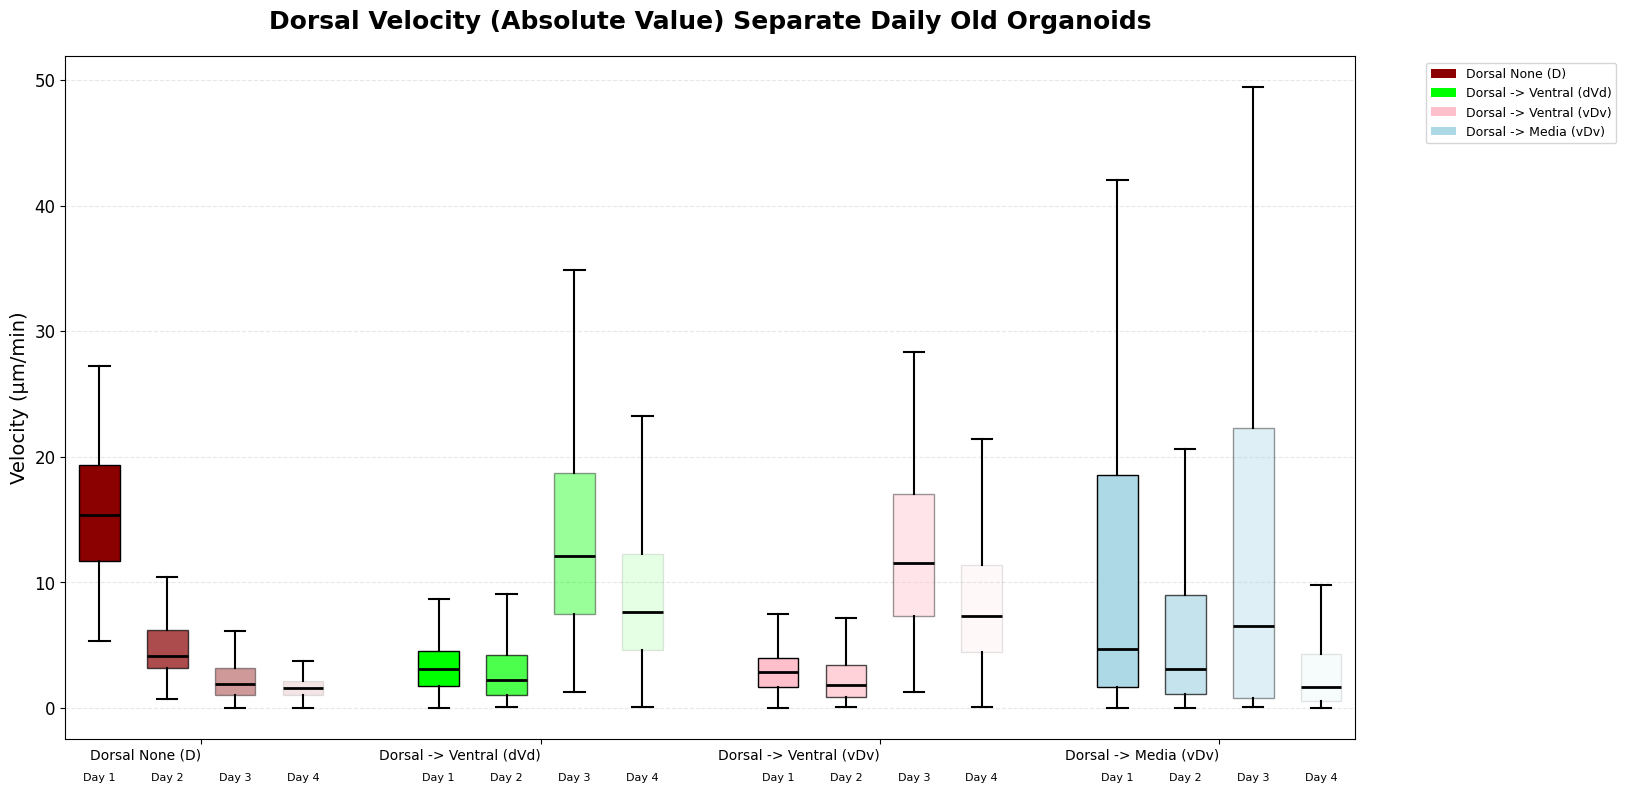


DORSAL VELOCITY ANALYSIS COMPLETE


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
from scipy import stats
import itertools

# ============================================================================
# STANDARDIZED PLOT CONFIGURATION
# ============================================================================
PLOT_CONFIG = {
    'figsize': (16, 8),
    'title_fontsize': 18,
    'title_weight': 'bold',
    'title_pad': 20,
    'label_fontsize': 14,
    'tick_fontsize': 12,
    'xtick_fontsize': 10,
    'legend_fontsize': 9,
    'box_width': 0.6,
    'line_width': 1.5,
    'median_width': 2,
    'dpi': 300,
    'alpha': 0.7,
    'grid_alpha': 0.3
}

# Load the Excel files
df_young = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')
df_old_ventral = pd.read_excel('6 Days Average Ventral Only (3).xlsx', sheet_name='6 Days Ventral Only-Average')
df_old_dvd = pd.read_excel('6 Days dVd average (2).xlsx', sheet_name='6 Days dVd-Average')
df_old_vdv = pd.read_excel('6 days vDv average.xlsx', sheet_name='6 days vDV - Average')
df_old_dorsal = pd.read_excel('6 Days Dorsal Only Average.xlsx', sheet_name="6 Days Dorsal Only Average")

# Clean column names by removing extra spaces
df_young.columns = [col.strip() for col in df_young.columns]
df_old_ventral.columns = [col.strip() for col in df_old_ventral.columns]
df_old_dvd.columns = [col.strip() for col in df_old_dvd.columns]
df_old_vdv.columns = [col.strip() for col in df_old_vdv.columns]
#df_old_dorsal.columns = [col.strip() for col in df_old_dorsal.columns]

# Combine old organoid data - handle duplicate column names
df_old = pd.concat([df_old_ventral, df_old_dvd, df_old_vdv, df_old_dorsal], axis=1)

# Check for duplicate column names
duplicate_columns = df_old.columns[df_old.columns.duplicated()].tolist()
if duplicate_columns:
    # Keep only the first occurrence of each column
    df_old = df_old.loc[:, ~df_old.columns.duplicated()]

# Define conditions based on the actual column names from your output
conditions = {
    'Dorsal None (D)': {
        'columns': [
            'Velocity Dorsal'
        ],
        'color': 'darkred'
    },
    'Dorsal -> Ventral (dVd)': {
        'columns': [
            'Velocity Dorsal->Ventral',
            'Velocity Dorsal->Ventral.1',
            'Velocity Dorsal->Ventral.2',
            'Velocity Dorsal->Ventral.3',
            'Velocity Dorsal->Ventral.4'
        ],
        'color': 'lime'
    },
    'Dorsal -> Ventral (vDv)': {
        'columns': [
            'Velocity Dorsal->Ventral',
            'Velcoity Dorsal->Ventral.1',
            'Velocity Dorsal->Ventral.2',
            'Velocity Dorsal->Ventral.3',
            'Velocity Dorsal->Ventral.4'
        ],
        'color': 'pink'
    },
    'Dorsal -> Media (vDv)': {
        'columns': [
            'Velocity Dorsal towards Media',
            'Velocity Dorsal towards Media.1',
            'Velocity Dorsal towards Media.2',
            'Velocity Dorsal towards Media.3',
            'Velocity Dorsal towards Media.4'
        ],
        'color': 'lightblue'
    }
}

# Define day ranges
day1 = [0, 24]    # Day 1: 0-24 hours
day2 = [24, 48]   # Day 2: 24-48 hours
day3 = [48, 72]   # Day 3: 48-72 hours
day4 = [72, 96]   # Day 4: 72-96 hours

# Function to remove outliers using IQR method
def remove_outliers(data):
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Function to convert p-value to significance stars
def get_significance_stars(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return 'ns'

# Function to perform statistical test between two datasets
def perform_statistical_test(data1, data2):
    if len(data1) == 0 or len(data2) == 0:
        return np.nan

    # Check normality
    if len(data1) > 7:  # normaltest requires at least 8 samples
        _, p_normal1 = stats.normaltest(data1)
    else:
        p_normal1 = 0.05  # Assume non-normal for small samples

    if len(data2) > 7:
        _, p_normal2 = stats.normaltest(data2)
    else:
        p_normal2 = 0.05  # Assume non-normal for small samples

    # Use appropriate test based on normality
    if p_normal1 < 0.05 or p_normal2 < 0.05:
        # Non-parametric test
        try:
            _, p_value = stats.mannwhitneyu(data1, data2)
        except:
            p_value = 1.0
    else:
        # Parametric test
        _, p_value = stats.ttest_ind(data1, data2)

    return p_value

# Store all data for statistical testing
all_data = {}
condition_names = list(conditions.keys())

# Create figure with standardized dimensions
fig = plt.figure(figsize=PLOT_CONFIG['figsize'])

# For each condition, extract data for each day and create boxplots
for i, (cond_name, cond_info) in enumerate(conditions.items()):
    # Get all valid columns for this condition that exist in the dataframe
    cols = [col for col in cond_info['columns'] if col in df_old.columns]

    if not cols:  # Skip if no valid columns found
        print(f"Warning: No valid columns found for {cond_name}")
        continue

    print(f"Processing {cond_name} with columns: {cols}")

    # Extract data for each day with safe filtering
    # Use the first time column (we removed duplicates)
    time_col = 'Time (hr)'
    if time_col in df_old.columns:
        # Make sure we're using the correct time column (first occurrence)
        day1_data = np.abs(df_old[(df_old[time_col] >= day1[0]) & (df_old[time_col] < day1[1])][cols].values.flatten())
        day2_data = np.abs(df_old[(df_old[time_col] >= day2[0]) & (df_old[time_col] < day2[1])][cols].values.flatten())
        day3_data = np.abs(df_old[(df_old[time_col] >= day3[0]) & (df_old[time_col] < day3[1])][cols].values.flatten())
        day4_data = np.abs(df_old[(df_old[time_col] >= day4[0]) & (df_old[time_col] < day4[1])][cols].values.flatten())

        print(f"{cond_name} - Day 1 data points: {len(day1_data)}")
        print(f"{cond_name} - Day 2 data points: {len(day2_data)}")
        print(f"{cond_name} - Day 3 data points: {len(day3_data)}")
        print(f"{cond_name} - Day 4 data points: {len(day4_data)}")
    else:
        print("Warning: 'Time (hr)' column not found. Using all data without time filtering.")
        # Use all data if time column doesn't exist
        day1_data = np.abs(df_old[cols].values.flatten())
        day2_data = np.array([])
        day3_data = np.array([])
        day4_data = np.array([])

    # Remove NaN values and outliers
    day1_data = remove_outliers(day1_data[~np.isnan(day1_data)])
    day2_data = remove_outliers(day2_data[~np.isnan(day2_data)])
    day3_data = remove_outliers(day3_data[~np.isnan(day3_data)])
    day4_data = remove_outliers(day4_data[~np.isnan(day4_data)])

    # Store data for statistical testing
    all_data[cond_name] = {
        'day1': day1_data,
        'day2': day2_data,
        'day3': day3_data,
        'day4': day4_data
    }

    # Create positions for boxplots (grouped by condition)
    positions = [i*5, i*5+1, i*5+2, i*5+3]  # Increased spacing to 5

    # Get the color for this condition
    base_color = cond_info['color']

    # Create boxplots with different transparency for each day - standardized parameters
    if len(day1_data) > 0:
        plt.boxplot(day1_data, positions=[positions[0]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=1.0, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

    if len(day2_data) > 0:
        plt.boxplot(day2_data, positions=[positions[1]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=0.7, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

    if len(day3_data) > 0:
        plt.boxplot(day3_data, positions=[positions[2]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=0.4, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

    if len(day4_data) > 0:
        plt.boxplot(day4_data, positions=[positions[3]], widths=PLOT_CONFIG['box_width'],
                   patch_artist=True,
                   boxprops=dict(facecolor=base_color, alpha=0.1, edgecolor='black'),
                   medianprops=dict(color='black', linewidth=PLOT_CONFIG['median_width']),
                   whiskerprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   capprops=dict(color='black', linewidth=PLOT_CONFIG['line_width']),
                   showfliers=False)

# Calculate and print p-value comparisons
print("\n" + "=" * 80)
print("P-VALUE ANALYSIS: COMPARISON BETWEEN DORSAL VELOCITY CONDITIONS WITHIN EACH DAY")
print("=" * 80)

days = ['day1', 'day2', 'day3', 'day4']

for day in days:
    print(f"\n{day.upper()} (Hours {eval(day)[0]}-{eval(day)[1]}):")
    print("-" * 40)

    # Compare all pairs of conditions
    for i, j in itertools.combinations(range(len(condition_names)), 2):
        cond1 = condition_names[i]
        cond2 = condition_names[j]

        data1 = all_data[cond1][day]
        data2 = all_data[cond2][day]

        p_value = perform_statistical_test(data1, data2)

        if not np.isnan(p_value):
            star = get_significance_stars(p_value)
            print(f"{cond1} vs {cond2}: p = {p_value:.4f} {star}")
        else:
            print(f"{cond1} vs {cond2}: Insufficient data")

# Customize the plot with standardized fonts
plt.title('Dorsal Velocity (Absolute Value) Separate Daily Old Organoids',
          fontsize=PLOT_CONFIG['title_fontsize'],
          fontweight=PLOT_CONFIG['title_weight'],
          pad=PLOT_CONFIG['title_pad'])
plt.ylabel('Velocity (μm/min)', fontsize=PLOT_CONFIG['label_fontsize'])

# Set x-ticks and labels with standardized font size
xticks = [i*5+1.5 for i in range(len(conditions))]  # Adjusted for new spacing
plt.xticks(xticks, conditions.keys(), rotation=0, ha='right',
           fontsize=PLOT_CONFIG['xtick_fontsize'])
plt.yticks(fontsize=PLOT_CONFIG['tick_fontsize'])

# Add day indicators below x-axis with standardized font size
y_min, y_max = plt.ylim()
for i, cond in enumerate(conditions):
    plt.text(i*5+0, y_min - 0.05*(y_max-y_min), 'Day 1',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')
    plt.text(i*5+1, y_min - 0.05*(y_max-y_min), 'Day 2',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')
    plt.text(i*5+2, y_min - 0.05*(y_max-y_min), 'Day 3',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')
    plt.text(i*5+3, y_min - 0.05*(y_max-y_min), 'Day 4',
             ha='center', va='top', fontsize=PLOT_CONFIG['xtick_fontsize']-2,
             color='black')

# Create legend for conditions using their defined colors with standardized font size
legend_elements = [Patch(facecolor=cond_info['color'], label=cond_name)
                  for cond_name, cond_info in conditions.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left',
           fontsize=PLOT_CONFIG['legend_fontsize'])

# Add grid and adjust layout with standardized alpha
plt.grid(True, axis='y', linestyle='--', alpha=PLOT_CONFIG['grid_alpha'])
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Consistent margin for legend

plt.show()

# Optional: Save with standardized DPI
# plt.savefig('dorsal_daily_velocity_comparison.png', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')

print("\n" + "=" * 80)
print("DORSAL VELOCITY ANALYSIS COMPLETE")
print("=" * 80)

p-value comparison

/tmp/ipython-input-621631827.py:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


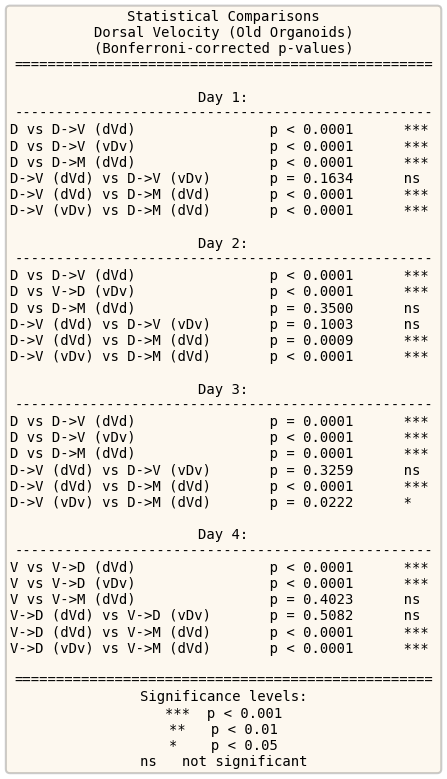


VENTRAL DISPLACEMENT (YOUNG ORGANOIDS) STATISTICAL SUMMARY
Total comparisons: 24
Significant comparisons (p < 0.001): 17
Significant comparisons (p < 0.01): 0
Significant comparisons (p < 0.05): 1

By Day:
  Day 1: 5/6 significant
  Day 2: 4/6 significant
  Day 3: 5/6 significant
  Day 4: 4/6 significant
Figure saved as: ventral_displacement_young_pvalue_legend_6x6.png


In [ ]:
# ======================================================================
# CREATE SEPARATE 6x6 P-VALUE LEGEND FIGURE - VENTRAL DISPLACEMENT (YOUNG)
# ======================================================================
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np

# Your p-value data organized

pvalue_data = {
    'Day 1': [
        ('D vs D->V (dVd)', 0.0000, '***'),
        ('D vs D->V (vDv)', 0.0000, '***'),
        ('D vs D->M (dVd)', 0.0000, '***'),
        ('D->V (dVd) vs D->V (vDv)', 0.1634, 'ns'),
        ('D->V (dVd) vs D->M (dVd)', 0.0000, '***'),
        ('D->V (vDv) vs D->M (dVd)', 0.0000, '***')
    ],
    'Day 2': [
        ('D vs D->V (dVd)', 0.0000, '***'),
        ('D vs V->D (vDv)', 0.0000, '***'),
        ('D vs D->M (dVd)', 0.3500, 'ns'),
        ('D->V (dVd) vs D->V (vDv)', 0.1003, 'ns'),
        ('D->V (dVd) vs D->M (dVd)', 0.0009, '***'),
        ('D->V (vDv) vs D->M (dVd)', 0.0000, '***')
    ],
    'Day 3': [
        ('D vs D->V (dVd)', 0.0001, '***'),
        ('D vs D->V (vDv)', 0.0000, '***'),
        ('D vs D->M (dVd)', 0.0001, '***'),
        ('D->V (dVd) vs D->V (vDv)', 0.3259, 'ns'),
        ('D->V (dVd) vs D->M (dVd)', 0.0000, '***'),
        ('D->V (vDv) vs D->M (dVd)', 0.0222, '*')
    ],
    'Day 4': [
        ('V vs V->D (dVd)', 0.0000, '***'),
        ('V vs V->D (vDv)', 0.0000, '***'),
        ('V vs V->M (dVd)', 0.4023, 'ns'),
        ('V->D (dVd) vs V->D (vDv)', 0.5082, 'ns'),
        ('V->D (dVd) vs V->M (dVd)', 0.0000, '***'),
        ('V->D (vDv) vs V->M (dVd)', 0.0000, '***')
    ]
}

# Create 6x6 figure for p-values
fig_pval = plt.figure(figsize=(3, 3))
ax_pval = fig_pval.add_subplot(111)

# Remove axes
ax_pval.axis('off')

# Build text content
p_text_lines = []
p_text_lines.append("Statistical Comparisons")
p_text_lines.append("Dorsal Velocity (Old Organoids)")
p_text_lines.append("(Bonferroni-corrected p-values)")
p_text_lines.append("=" * 50)
p_text_lines.append("")

for day_num, (day, comparisons) in enumerate(pvalue_data.items(), 1):
    p_text_lines.append(f"{day}:")
    p_text_lines.append("-" * 50)

    for comp, pval, stars in comparisons:
        # Format p-value
        if pval < 0.0001:
            p_str = "p < 0.0001"
        else:
            p_str = f"p = {pval:.4f}"

        # Create formatted line
        line = f"{comp:30s} {p_str:15s} {stars:4s}"
        p_text_lines.append(line)

    p_text_lines.append("")

# Add legend
p_text_lines.append("=" * 50)
p_text_lines.append("Significance levels:")
p_text_lines.append("***  p < 0.001")
p_text_lines.append("**   p < 0.01")
p_text_lines.append("*    p < 0.05")
p_text_lines.append("ns   not significant")

# Join all lines
p_value_text = '\n'.join(p_text_lines)

# Add text to figure with box
props = dict(boxstyle='round', facecolor='wheat', alpha=0.2,
             edgecolor='black', linewidth=1.5)

ax_pval.text(0.5, 0.5, p_value_text,
            transform=ax_pval.transAxes,
            fontsize=10,
            verticalalignment='center',
            horizontalalignment='center',
            fontfamily='monospace',
            bbox=props)

plt.tight_layout()

# Save the figure
plt.savefig('ventral_displacement_young_pvalue_legend_6x6.png', dpi=300, bbox_inches='tight')
plt.show()

# Display summary statistics
print("\n" + "="*60)
print("VENTRAL DISPLACEMENT (YOUNG ORGANOIDS) STATISTICAL SUMMARY")
print("="*60)

total_comparisons = sum(len(comparisons) for comparisons in pvalue_data.values())
print(f"Total comparisons: {total_comparisons}")

# Count significant comparisons
significant_counts = {0.001: 0, 0.01: 0, 0.05: 0}
for day, comparisons in pvalue_data.items():
    for comp, pval, stars in comparisons:
        if pval < 0.001:
            significant_counts[0.001] += 1
        elif pval < 0.01:
            significant_counts[0.01] += 1
        elif pval < 0.05:
            significant_counts[0.05] += 1

print(f"Significant comparisons (p < 0.001): {significant_counts[0.001]}")
print(f"Significant comparisons (p < 0.01): {significant_counts[0.01]}")
print(f"Significant comparisons (p < 0.05): {significant_counts[0.05]}")

print("\nBy Day:")
for day, comparisons in pvalue_data.items():
    day_significant = sum(1 for comp, pval, stars in comparisons if pval < 0.05)
    print(f"  {day}: {day_significant}/{len(comparisons)} significant")

print("="*60)
print("Figure saved as: ventral_displacement_young_pvalue_legend_6x6.png")

## Comparison Graphs

P-VALUES FOR EACH CONDITION (Young vs Old)
Ventral Only (V): p = 0.000000
Ventral -> Dorsal (dVd): p = 0.000000
Ventral -> Dorsal (vDv): p = 0.000000
Ventral -> Media (dVd): p = 0.000000


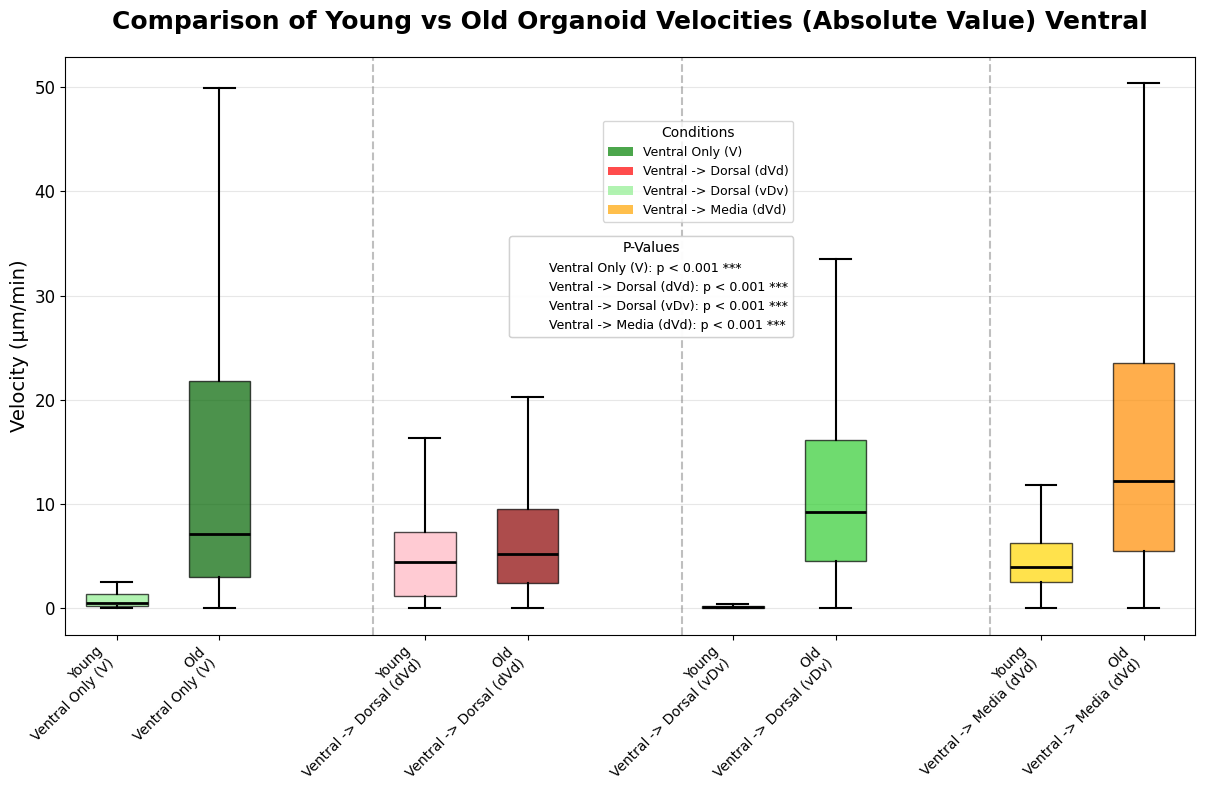

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
from scipy import stats

# ============================================================================
# STANDARDIZED PLOT CONFIGURATION
# ============================================================================
PLOT_CONFIG = {
    'figsize': (16, 8),
    'title_fontsize': 18,
    'title_weight': 'bold',
    'title_pad': 20,
    'label_fontsize': 14,
    'tick_fontsize': 12,
    'xtick_fontsize': 10,
    'legend_fontsize': 9,
    'box_width': 0.6,
    'line_width': 1.5,
    'median_width': 2,
    'dpi': 300,
    'alpha': 0.7,
    'grid_alpha': 0.3
}

# Load the Excel files
df_young = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')
df_old_ventral = pd.read_excel('6 Days Average Ventral Only (3).xlsx', sheet_name='6 Days Ventral Only-Average')
df_old_dvd = pd.read_excel('6 Days dVd average (2).xlsx', sheet_name='6 Days dVd-Average')
df_old_vdv = pd.read_excel('6 days vDv average.xlsx', sheet_name='6 days vDV - Average')

# Clean column names by removing extra spaces
df_young.columns = [col.strip() for col in df_young.columns]
df_old_ventral.columns = [col.strip() for col in df_old_ventral.columns]
df_old_dvd.columns = [col.strip() for col in df_old_dvd.columns]
df_old_vdv.columns = [col.strip() for col in df_old_vdv.columns]

# Combine old organoid data
df_old = pd.concat([df_old_ventral, df_old_dvd, df_old_vdv], axis=1)

# Define the conditions dictionary with colors
conditions = {
    # 1. Ventral only (V)
    'Ventral Only (V)': {
        'columns': [
            'Velocity C1: Ventral Only',
            'Velocity C1: VentralOnly',
            'Velocity: C1 Ventral Only',
            'Velocity 1V',
            'Velocity 2V',
            'Velocity 3V',
            'Velocity 4V'
        ],
        'color': 'green'
    },
    # 2. Ventral -> Dorsal (dVd)
    'Ventral -> Dorsal (dVd)': {
        'columns': [
            'Velocity: C2 VentralCenter Green',
            'Velocity: C2 Ventral Center Green',
            'Velocity Dorsal->Ventral',
            'Velocity Dorsal->Ventral.1',
            'Velocity Dorsal->Ventral.2',
            'Velocity Dorsal->Ventral.3',
            'Velocity Dorsal->Ventral.4'
        ],
        'color': 'red'
    },
    # 3. Ventral ->Dorsal (vDv)
    'Ventral -> Dorsal (vDv)':{
        'columns': [
            'Velocity: C4 Dorsal Center Red',
            'Velocity Ventral->Dorsal',
            'Velocity Ventral->Dorsal.1',
            'Velocity Ventral->Dorsal.2',
            'Velocity Ventral->Dorsal.3',
            'Velocity Ventral->Dorsal.4'
        ],
        'color': 'lightgreen'
    },
    # 4. Ventral -> Media (dVd)
    'Ventral -> Media (dVd)': {
        'columns': [
            'Velocity: C2 VentralCenter towards Media',
            'Velocity Ventral towards media',
            'Velocity Ventral towards media.1',
            'Velocity Ventral towards media.2',
            'Velocity Ventral towards media.3',
            'Velocity Ventral towards media.4'
        ],
        'color': 'orange'
    },
}

# Function to remove outliers using IQR method
def remove_outliers(data):
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Prepare data for box plots
plot_data_young = []
plot_data_old = []
clean_condition_names = []
box_colors = []

# Store p-values for each condition
p_values = []

for condition, config in conditions.items():
    # Get valid columns that exist in the young dataframe
    valid_cols_young = [col for col in config['columns'] if col in df_young.columns]

    # Get valid columns that exist in the old dataframe
    valid_cols_old = [col for col in config['columns'] if col in df_old.columns]

    # Process young organoid data
    if valid_cols_young:
        young_velocities = np.abs(df_young[valid_cols_young].values.flatten())
        young_velocities = young_velocities[~np.isnan(young_velocities)]
        clean_young_velocities = remove_outliers(young_velocities)
    else:
        clean_young_velocities = np.array([])

    # Process old organoid data
    if valid_cols_old:
        old_velocities = np.abs(df_old[valid_cols_old].values.flatten())
        old_velocities = old_velocities[~np.isnan(old_velocities)]
        clean_old_velocities = remove_outliers(old_velocities)
    else:
        clean_old_velocities = np.array([])

    if len(clean_young_velocities) > 0 or len(clean_old_velocities) > 0:
        plot_data_young.append(clean_young_velocities)
        plot_data_old.append(clean_old_velocities)
        clean_condition_names.append(condition)
        box_colors.append(config['color'])

        # Calculate p-value for this condition (young vs old)
        if len(clean_young_velocities) > 0 and len(clean_old_velocities) > 0:
            # Use t-test for comparing two groups
            t_stat, p_value = stats.ttest_ind(clean_young_velocities, clean_old_velocities, equal_var=False)
            p_values.append(p_value)
        else:
            p_values.append(np.nan)

# Only proceed if we have data to plot
if plot_data_young or plot_data_old:
    # Create a single figure with standardized dimensions
    fig, ax = plt.subplots(figsize=PLOT_CONFIG['figsize'])

    # Set the positions for the boxes
    positions = []
    group_labels = []
    all_data = []
    box_colors_final = []

    # Prepare data for plotting
    for i, condition in enumerate(clean_condition_names):
        # Young data
        if i < len(plot_data_young) and len(plot_data_young[i]) > 0:
            positions.append(i * 3 + 1)
            all_data.append(plot_data_young[i])
            group_labels.append('Young\n' + condition)
            # Use lighter shade for young
            if box_colors[i] == 'green':
                box_colors_final.append('#90EE90')  # Light green
            elif box_colors[i] == 'red':
                box_colors_final.append('#FFB6C1')  # Light red
            elif box_colors[i] == 'lightgreen':
                box_colors_final.append('#98FB98')  # Pale green
            elif box_colors[i] == 'orange':
                box_colors_final.append('#FFD700')  # Gold (light orange)
            else:
                box_colors_final.append(box_colors[i])

        # Old data
        if i < len(plot_data_old) and len(plot_data_old[i]) > 0:
            positions.append(i * 3 + 2)
            all_data.append(plot_data_old[i])
            group_labels.append('Old\n' + condition)
            # Use darker shade for old
            if box_colors[i] == 'green':
                box_colors_final.append('#006400')  # Dark green
            elif box_colors[i] == 'red':
                box_colors_final.append('#8B0000')  # Dark red
            elif box_colors[i] == 'lightgreen':
                box_colors_final.append('#32CD32')  # Lime green
            elif box_colors[i] == 'orange':
                box_colors_final.append('#FF8C00')  # Dark orange
            else:
                box_colors_final.append(box_colors[i])

    # Create box plot with standardized parameters
    box = ax.boxplot(all_data, positions=positions, patch_artist=True,
                     showfliers=False, widths=PLOT_CONFIG['box_width'])

    # Apply custom colors to boxes
    for patch, color in zip(box['boxes'], box_colors_final):
        patch.set_facecolor(color)
        patch.set_alpha(PLOT_CONFIG['alpha'])

    # Customize whiskers, caps, and medians with standardized widths
    for element in ['whiskers', 'caps']:
        plt.setp(box[element], color='black', linewidth=PLOT_CONFIG['line_width'])
    plt.setp(box['medians'], color='black', linewidth=PLOT_CONFIG['median_width'])

    # Customize the plot with standardized fonts
    ax.set_title('Comparison of Young vs Old Organoid Velocities (Absolute Value) Ventral',
                 fontsize=PLOT_CONFIG['title_fontsize'],
                 fontweight=PLOT_CONFIG['title_weight'],
                 pad=PLOT_CONFIG['title_pad'])
    ax.set_ylabel('Velocity (μm/min)', fontsize=PLOT_CONFIG['label_fontsize'])
    ax.set_xticks(positions)
    ax.set_xticklabels(group_labels, rotation=45, ha='right', fontsize=PLOT_CONFIG['xtick_fontsize'])
    ax.tick_params(axis='y', labelsize=PLOT_CONFIG['tick_fontsize'])

    # Add grid with standardized alpha
    ax.grid(axis='y', alpha=PLOT_CONFIG['grid_alpha'])

    # Add vertical lines to separate conditions
    for i in range(len(clean_condition_names)):
        if i > 0:
            ax.axvline(x=i * 3 + 0.5, color='gray', linestyle='--', alpha=0.5)

    # Create separate legends
    # 1. Legend for condition colors
    condition_legend_elements = []
    for i, condition in enumerate(clean_condition_names):
        condition_legend_elements.append(
            Patch(facecolor=box_colors[i], alpha=PLOT_CONFIG['alpha'], label=condition)
        )

    # 2. Legend for p-values (with asterisks for significance)
    pvalue_legend_elements = []
    for i, condition in enumerate(clean_condition_names):
        if not np.isnan(p_values[i]):
            # Format p-value text with asterisks for significance
            if p_values[i] < 0.001:
                p_text = f'p < 0.001 ***'
            elif p_values[i] < 0.01:
                p_text = f'p < 0.01 **'
            elif p_values[i] < 0.05:
                p_text = f'p < 0.05 *'
            else:
                p_text = f'p = {p_values[i]:.3f}'

            pvalue_legend_elements.append(
                Patch(facecolor='white', alpha=0, label=f"{condition}: {p_text}")
            )
        else:
            pvalue_legend_elements.append(
                Patch(facecolor='white', alpha=0, label=f"{condition}: Not enough data")
            )

    # Add legends to the plot with standardized font size
    legend1 = ax.legend(handles=condition_legend_elements, loc='upper right',
                         bbox_to_anchor=(0.65, 0.9), title="Conditions",
                         fontsize=PLOT_CONFIG['legend_fontsize'])
    legend3 = ax.legend(handles=pvalue_legend_elements, loc='upper right',
                         bbox_to_anchor=(0.65, 0.7), title="P-Values",
                         fontsize=PLOT_CONFIG['legend_fontsize'])

    # Manually add the legends to the plot
    ax.add_artist(legend1)
    ax.add_artist(legend3)

    plt.tight_layout()
    plt.subplots_adjust(right=0.75)  # Adjust right margin to accommodate legends

    # Print p-values in console for reference
    print("=" * 60)
    print("P-VALUES FOR EACH CONDITION (Young vs Old)")
    print("=" * 60)
    for i, condition in enumerate(clean_condition_names):
        if not np.isnan(p_values[i]):
            print(f"{condition}: p = {p_values[i]:.6f}")
        else:
            print(f"{condition}: Not enough data for comparison")
    print("=" * 60)

    plt.show()

    # Optional: Save with standardized DPI
    # plt.savefig('ventral_velocity_comparison.png', dpi=PLOT_CONFIG['dpi'], bbox_inches='tight')
else:
    print("No valid data found for any condition.")


P-VALUES FOR EACH CONDITION (Young vs Old)
Dorsal Only (D): p = 0.291726
Dorsal -> Ventral (dVd): p = 0.049603
Dorsal -> Ventral (vDv): p = 0.000000
Dorsal -> Media (vDv): p = 0.000000


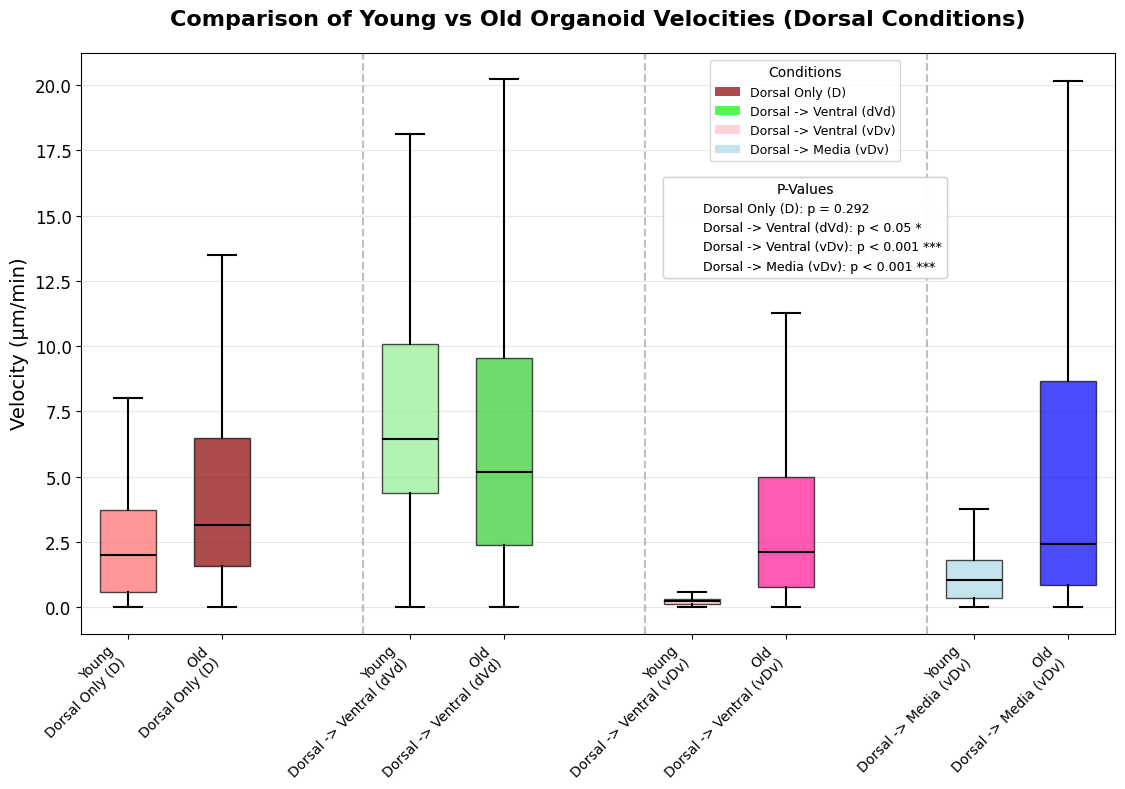

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
import seaborn as sns
from scipy import stats

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("colorblind")

PLOT_CONFIG = {
    'figsize': (16, 8),
    'title_fontsize': 18,
    'title_weight': 'bold',
    'title_pad': 20,
    'label_fontsize': 14,
    'tick_fontsize': 12,
    'xtick_fontsize': 10,
    'legend_fontsize': 9,
    'box_width': 0.6,
    'line_width': 1.5,
    'median_width': 2,
    'dpi': 300,
    'alpha': 0.7,
    'grid_alpha': 0.3
}



# Load the Excel files
df_young = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')
df_old_ventral = pd.read_excel('6 Days Average Ventral Only (3).xlsx', sheet_name='6 Days Ventral Only-Average')
df_old_dvd = pd.read_excel('6 Days dVd average (2).xlsx', sheet_name='6 Days dVd-Average')
df_old_vdv = pd.read_excel('6 days vDv average.xlsx', sheet_name='6 days vDV - Average')
df_old_dorsal = pd.read_excel('6 Days Dorsal Only Average.xlsx', sheet_name="6 Days Dorsal Only Average")

# Clean column names by removing extra spaces
df_young.columns = [col.strip() for col in df_young.columns]
df_old_ventral.columns = [col.strip() for col in df_old_ventral.columns]
df_old_dvd.columns = [col.strip() for col in df_old_dvd.columns]
df_old_vdv.columns = [col.strip() for col in df_old_vdv.columns]
#df_old_dorsal.columns = [col.strip() for col in df_old_dorsal.columns]  # Fixed this line

# Combine old organoid data
df_old = pd.concat([df_old_ventral, df_old_dvd, df_old_vdv, df_old_dorsal], axis=1)

# Define conditions with their columns and colors
conditions = {
    # 5. Dorsal Only (D)
    'Dorsal Only (D)': {
        'columns': [
            'Velocity: C3 Dorsal Only Red',
            'Velocity Dorsal',
            'Velocity'
        ],
        'color': 'darkred'
    },
    # 6. Dorsal -> Ventral (dVd)
    'Dorsal -> Ventral (dVd)': {
        'columns': [
            'C2 VentralCenter Red',
            'Velocity Dorsal->Ventral',
            'Velocity Dorsal->Ventral.1',
            'Velocity Dorsal->Ventral.2',
            'Velocity Dorsal->Ventral.3',
            'Velocity Dorsal->Ventral.4'

        ],
        'color': 'lime'
    },
    # 7. Dorsal -> Ventral (vDv)
    'Dorsal -> Ventral (vDv)': {
        'columns': [
            'Velocity C4:DorsalCenter Green',
            'Velocity Dorsal ->Ventral',
            'Velocity Dorsal ->Ventral.1',
            'Velocity Dorsal ->Ventral.2',
            'Velocity Dorsal ->Ventral.3',
            'Velocity Dorsal ->Vental.4'
        ],
        'color': 'pink'
    },
    # 8. Dorsal -> Media (vDv)
    'Dorsal -> Media (vDv)': {
        'columns': [
            'Velocity: C4 DorsalCenter towards Media',
            'Velocity Dorsal towards Media',
            'Velocity Dorsal towards Media.1',
            'Velocity Dorsal towards Media.2',
            'Velocity Dorsal towards Media.3',
            'Velocity Dorsal towards Media.4'
        ],
        'color': 'lightblue'
    }
}

# Function to remove outliers using IQR method
def remove_outliers(data):
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Prepare data for box plots
plot_data_young = []
plot_data_old = []
clean_condition_names = []
box_colors = []

# Store p-values for each condition
p_values = []

for condition, config in conditions.items():
    # Get valid columns that exist in the young dataframe
    valid_cols_young = [col for col in config['columns'] if col in df_young.columns]

    # Get valid columns that exist in the old dataframe
    valid_cols_old = [col for col in config['columns'] if col in df_old.columns]

    # Process young organoid data
    if valid_cols_young:
        young_velocities = np.abs(df_young[valid_cols_young].values.flatten())
        young_velocities = young_velocities[~np.isnan(young_velocities)]
        clean_young_velocities = remove_outliers(young_velocities)
    else:
        clean_young_velocities = np.array([])

    # Process old organoid data
    if valid_cols_old:
        old_velocities = np.abs(df_old[valid_cols_old].values.flatten())
        old_velocities = old_velocities[~np.isnan(old_velocities)]
        clean_old_velocities = remove_outliers(old_velocities)
    else:
        clean_old_velocities = np.array([])

    if len(clean_young_velocities) > 0 or len(clean_old_velocities) > 0:
        plot_data_young.append(clean_young_velocities)
        plot_data_old.append(clean_old_velocities)
        clean_condition_names.append(condition)
        box_colors.append(config['color'])

        # Calculate p-value for this condition (young vs old)
        if len(clean_young_velocities) > 0 and len(clean_old_velocities) > 0:
            # Use t-test for comparing two groups
            t_stat, p_value = stats.ttest_ind(clean_young_velocities, clean_old_velocities, equal_var=False)
            p_values.append(p_value)
        else:
            p_values.append(np.nan)

# Only proceed if we have data to plot
if plot_data_young or plot_data_old:
    # Create a single figure with better dimensions
    fig, ax = plt.subplots(figsize=(16, 8))  # Wider and shorter figure

    # Set the positions for the boxes
    positions = []
    group_labels = []
    all_data = []
    box_colors_final = []

    # Prepare data for plotting
    for i, condition in enumerate(clean_condition_names):
        # Young data
        if i < len(plot_data_young) and len(plot_data_young[i]) > 0:
            positions.append(i * 3 + 1)
            all_data.append(plot_data_young[i])
            group_labels.append('Young\n' + condition)
            # Use lighter shade for young
            if box_colors[i] == 'darkred':
                box_colors_final.append('#FF6B6B')  # Light red
            elif box_colors[i] == 'lime':
                box_colors_final.append('#90EE90')  # Light lime
            elif box_colors[i] == 'pink':
                box_colors_final.append('#FFB6C1')  # Light pink
            elif box_colors[i] == 'lightblue':
                box_colors_final.append('#ADD8E6')  # Light blue
            else:
                box_colors_final.append(box_colors[i])

        # Old data
        if i < len(plot_data_old) and len(plot_data_old[i]) > 0:
            positions.append(i * 3 + 2)
            all_data.append(plot_data_old[i])
            group_labels.append('Old\n' + condition)
            # Use darker shade for old
            if box_colors[i] == 'darkred':
                box_colors_final.append('#8B0000')  # Dark red
            elif box_colors[i] == 'lime':
                box_colors_final.append('#32CD32')  # Dark lime
            elif box_colors[i] == 'pink':
                box_colors_final.append('#FF1493')  # Deep pink
            elif box_colors[i] == 'lightblue':
                box_colors_final.append('#0000FF')  # Blue
            else:
                box_colors_final.append(box_colors[i])

    # Create box plot
    box = ax.boxplot(all_data, positions=positions, patch_artist=True, showfliers=False, widths=0.6)

    # Apply custom colors to boxes
    for patch, color in zip(box['boxes'], box_colors_final):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Customize whiskers, caps, etc.
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(box[element], color='black', linewidth=1.5)

    # Customize the plot
    ax.set_title('Comparison of Young vs Old Organoid Velocities (Dorsal Conditions)', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Velocity (μm/min)', fontsize=14)
    ax.set_xticks(positions)
    ax.set_xticklabels(group_labels, rotation=45, ha='right', fontsize=10)
    ax.tick_params(axis='y', labelsize=12)

    # Add grid and adjust layout
    ax.grid(axis='y', alpha=0.3)

    # Add vertical lines to separate conditions
    for i in range(len(clean_condition_names)):
        if i > 0:
            ax.axvline(x=i * 3 + 0.5, color='gray', linestyle='--', alpha=0.5)

    # Create separate legends
    # 1. Legend for condition colors
    condition_legend_elements = []
    for i, condition in enumerate(clean_condition_names):
        condition_legend_elements.append(
            Patch(facecolor=box_colors[i], alpha=0.7, label=condition)
        )

    # 2. Legend for age groups
    age_legend_elements = [
        Patch(facecolor='lightgray', alpha=0.7, label='Young'),
        Patch(facecolor='darkgray', alpha=0.7, label='Old')
    ]

    # 3. Legend for p-values (with asterisks for significance)
    pvalue_legend_elements = []
    for i, condition in enumerate(clean_condition_names):
        if not np.isnan(p_values[i]):
            # Format p-value text with asterisks for significance
            if p_values[i] < 0.001:
                p_text = f'p < 0.001 ***'
            elif p_values[i] < 0.01:
                p_text = f'p < 0.01 **'
            elif p_values[i] < 0.05:
                p_text = f'p < 0.05 *'
            else:
                p_text = f'p = {p_values[i]:.3f}'

            pvalue_legend_elements.append(
                Patch(facecolor='white', alpha=0, label=f"{condition}: {p_text}")
            )
        else:
            pvalue_legend_elements.append(
                Patch(facecolor='white', alpha=0, label=f"{condition}: Not enough data")
            )

    # Add legends to the plot
    legend1 = ax.legend(handles=condition_legend_elements, loc='center',
                         bbox_to_anchor=(0.7, 0.9), title="Conditions", fontsize=9)
    legend3 = ax.legend(handles=pvalue_legend_elements, loc='center',
                         bbox_to_anchor=(0.7, 0.7), title="P-Values", fontsize=9)

    # Manually add the legends to the plot
    ax.add_artist(legend1)
    ax.add_artist(legend3)

    plt.tight_layout()
    plt.subplots_adjust(right=0.7)  # Adjust right margin to accommodate legends

    # Print p-values in console for reference
    print("=" * 60)
    print("P-VALUES FOR EACH CONDITION (Young vs Old)")
    print("=" * 60)
    for i, condition in enumerate(clean_condition_names):
        if not np.isnan(p_values[i]):
            print(f"{condition}: p = {p_values[i]:.6f}")
        else:
            print(f"{condition}: Not enough data for comparison")
    print("=" * 60)

    plt.show()
else:
    print("No valid data found for any condition.")


plt.savefig('dorsal_velocities_comparison.png', dpi=300, bbox_inches='tight')

P-VALUES FOR EACH CONDITION (Young vs Old)
Dorsal Only (D): p = 0.000000
Dorsal -> Ventral (dVd): p = 0.000014
Dorsal -> Ventral (vDv): p = 0.000000
Dorsal -> Media (vDv): p = 0.000000


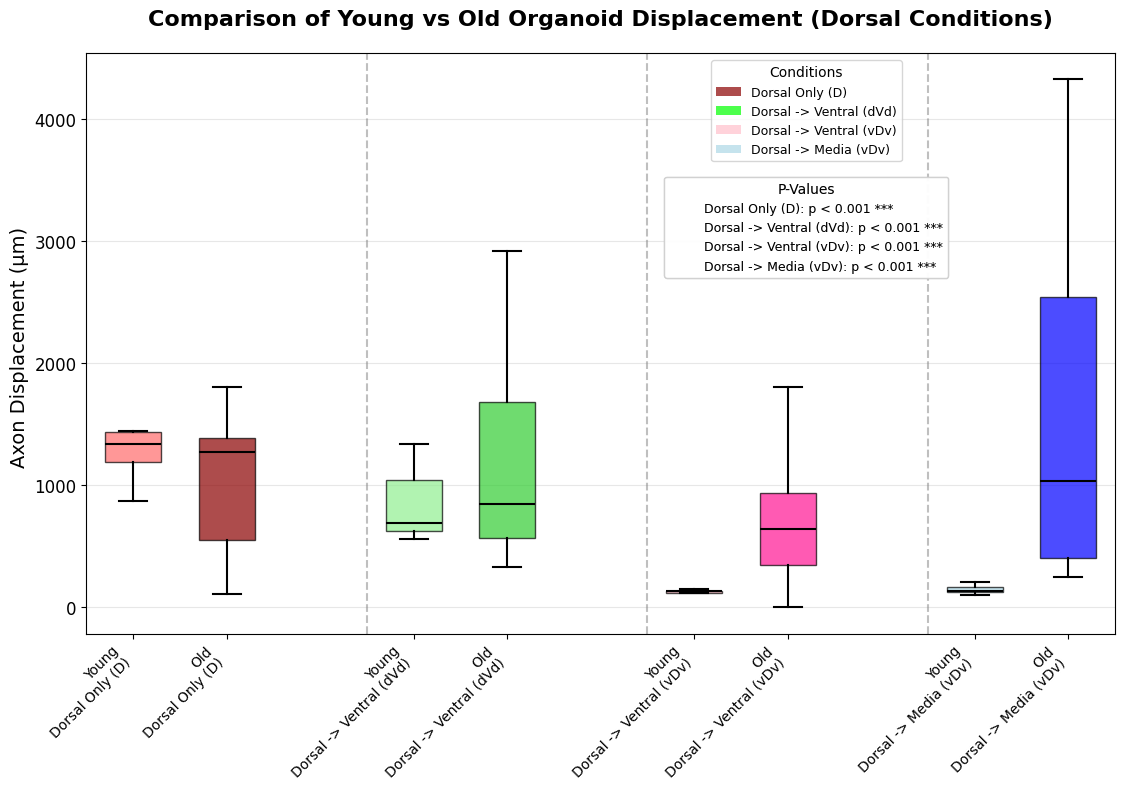

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
import seaborn as sns
from scipy import stats

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("colorblind")

# Load the Excel files
df_young = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')
df_old_ventral = pd.read_excel('6 Days Average Ventral Only (3).xlsx', sheet_name='6 Days Ventral Only-Average')
df_old_dvd = pd.read_excel('6 Days dVd average (2).xlsx', sheet_name='6 Days dVd-Average')
df_old_vdv = pd.read_excel('6 days vDv average.xlsx', sheet_name='6 days vDV - Average')
df_old_dorsal = pd.read_excel('6 Days Dorsal Only Average.xlsx', sheet_name="6 Days Dorsal Only Average")

# Clean column names by removing extra spaces
df_young.columns = [col.strip() for col in df_young.columns]
df_old_ventral.columns = [col.strip() for col in df_old_ventral.columns]
df_old_dvd.columns = [col.strip() for col in df_old_dvd.columns]
df_old_vdv.columns = [col.strip() for col in df_old_vdv.columns]
#df_old_dorsal.columns = [col.strip() for col in df_old_dorsal.columns]  # Fixed this line

# Combine old organoid data
df_old = pd.concat([df_old_ventral, df_old_dvd, df_old_vdv, df_old_dorsal], axis=1)

# Define conditions with their columns and colors
conditions = {
    # 5. Dorsal Only (D)
    'Dorsal Only (D)': {
        'columns': ['Condition#3 Dorsal Only Red',
            'Average'
        ],
        'color': 'darkred'
    },
    # 6. Dorsal -> Ventral (dVd)
    'Dorsal -> Ventral (dVd)': {
        'columns': [
            'Condition#2 VentralCenter Red',
            'Dorsal->Ventral',
            'Dorsal->Ventral.1',
            'Dorsal->Ventral.2',
            'Dorsal->Ventral.3',
            'Dorsal->Ventral.4'
        ],
        'color': 'lime'
    },
    # 7. Dorsal -> Ventral (vDv)
    'Dorsal -> Ventral (vDv)': {
        'columns': [
            'Condition#4 Dorsal Center Red',
            'Dorsal -> Ventral',
            'Dorsal -> Ventral.1',
            'Dorsal -> Ventral.2',
            'Dorsal -> Ventral.3',
            'Dorsal -> Ventral.4'
        ],
        'color': 'pink'
    },
    # 8. Dorsal -> Media (vDv)
    'Dorsal -> Media (vDv)': {
        'columns': [
            'Condition#4 Dorsal Center Red toward Media',
            'Dorsal towards media',
            'Dorsal towards media.1',
            'Dorsal towards media.2',
            'Dorsal towards media.3',
            'Dorsal towards media.4'
        ],
        'color': 'lightblue'
    }
}

# Function to remove outliers using IQR method
def remove_outliers(data):
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Prepare data for box plots
plot_data_young = []
plot_data_old = []
clean_condition_names = []
box_colors = []

# Statistical test results storage
stat_test_results = []
p_values = []

for condition, config in conditions.items():
    # Get valid columns that exist in the young dataframe
    valid_cols_young = [col for col in config['columns'] if col in df_young.columns]

    # Get valid columns that exist in the old dataframe
    valid_cols_old = [col for col in config['columns'] if col in df_old.columns]

    # Process young organoid data
    if valid_cols_young:
        young_velocities = np.abs(df_young[valid_cols_young].values.flatten())
        young_velocities = young_velocities[~np.isnan(young_velocities)]
        clean_young_velocities = remove_outliers(young_velocities)
    else:
        clean_young_velocities = np.array([])

    # Process old organoid data
    if valid_cols_old:
        old_velocities = np.abs(df_old[valid_cols_old].values.flatten())
        old_velocities = old_velocities[~np.isnan(old_velocities)]
        clean_old_velocities = remove_outliers(old_velocities)
    else:
        clean_old_velocities = np.array([])

    # Calculate p-value using Mann-Whitney U test
    if len(clean_young_velocities) > 3 and len(clean_old_velocities) > 3:
        stat, p_value = stats.mannwhitneyu(clean_young_velocities, clean_old_velocities)
        p_values.append(p_value)
    else:
        p_values.append(np.nan)

    if len(clean_young_velocities) > 0 or len(clean_old_velocities) > 0:
        plot_data_young.append(clean_young_velocities)
        plot_data_old.append(clean_old_velocities)
        clean_condition_names.append(condition)
        box_colors.append(config['color'])

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(16, 8))

# Only proceed if we have data to plot
if plot_data_young or plot_data_old:
    # Set the positions for the boxes
    positions = []
    group_labels = []
    all_data = []
    box_colors_final = []

    # Prepare data for plotting
    for i, condition in enumerate(clean_condition_names):
        # Young data
        if i < len(plot_data_young) and len(plot_data_young[i]) > 0:
            positions.append(i * 3 + 1)
            all_data.append(plot_data_young[i])
            group_labels.append('Young\n' + condition)
            # Use lighter shade for young
            if box_colors[i] == 'darkred':
                box_colors_final.append('#FF6B6B')  # Light red
            elif box_colors[i] == 'lime':
                box_colors_final.append('#90EE90')  # Light lime
            elif box_colors[i] == 'pink':
                box_colors_final.append('#FFB6C1')  # Light pink
            elif box_colors[i] == 'lightblue':
                box_colors_final.append('#ADD8E6')  # Light blue
            else:
                box_colors_final.append(box_colors[i])

        # Old data
        if i < len(plot_data_old) and len(plot_data_old[i]) > 0:
            positions.append(i * 3 + 2)
            all_data.append(plot_data_old[i])
            group_labels.append('Old\n' + condition)
            # Use darker shade for old
            if box_colors[i] == 'darkred':
                box_colors_final.append('#8B0000')  # Dark red
            elif box_colors[i] == 'lime':
                box_colors_final.append('#32CD32')  # Dark lime
            elif box_colors[i] == 'pink':
                box_colors_final.append('#FF1493')  # Deep pink
            elif box_colors[i] == 'lightblue':
                box_colors_final.append('#0000FF')  # Blue
            else:
                box_colors_final.append(box_colors[i])

    # Create box plot
    box = ax1.boxplot(all_data, positions=positions, patch_artist=True, showfliers=False, widths=0.6)

    # Apply custom colors to boxes
    for patch, color in zip(box['boxes'], box_colors_final):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Customize whiskers, caps, etc.
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(box[element], color='black', linewidth=1.5)

    # Customize the plot - using ax1 instead of ax
    ax1.set_title('Comparison of Young vs Old Organoid Displacement (Dorsal Conditions)', fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel('Axon Displacement (μm) ', fontsize=14)
    ax1.set_xticks(positions)
    ax1.set_xticklabels(group_labels, rotation=45, ha='right', fontsize=10)
    ax1.tick_params(axis='y', labelsize=12)

    # Add grid and adjust layout
    ax1.grid(axis='y', alpha=0.3)

    # Add vertical lines to separate conditions
    for i in range(len(clean_condition_names)):
        if i > 0:
            ax1.axvline(x=i * 3 + 0.5, color='gray', linestyle='--', alpha=0.5)

    # Create separate legends
    # 1. Legend for condition colors
    condition_legend_elements = []
    for i, condition in enumerate(clean_condition_names):
        condition_legend_elements.append(
            Patch(facecolor=box_colors[i], alpha=0.7, label=condition)
        )

    # 2. Legend for age groups
    age_legend_elements = [
        Patch(facecolor='lightgray', alpha=0.7, label='Young'),
        Patch(facecolor='darkgray', alpha=0.7, label='Old')
    ]

    # 3. Legend for p-values (with asterisks for significance)
    pvalue_legend_elements = []
    for i, condition in enumerate(clean_condition_names):
        if not np.isnan(p_values[i]):
            # Format p-value text with asterisks for significance
            if p_values[i] < 0.001:
                p_text = f'p < 0.001 ***'
            elif p_values[i] < 0.01:
                p_text = f'p < 0.01 **'
            elif p_values[i] < 0.05:
                p_text = f'p < 0.05 *'
            else:
                p_text = f'p = {p_values[i]:.3f}'

            pvalue_legend_elements.append(
                Patch(facecolor='white', alpha=0, label=f"{condition}: {p_text}")
            )
        else:
            pvalue_legend_elements.append(
                Patch(facecolor='white', alpha=0, label=f"{condition}: Not enough data")
            )

    # Add legends to the plot - using ax1 instead of ax
    legend1 = ax1.legend(handles=condition_legend_elements, loc='center',
                         bbox_to_anchor=(0.7, 0.9), title="Conditions", fontsize=9)
    legend3 = ax1.legend(handles=pvalue_legend_elements, loc='center',
                         bbox_to_anchor=(0.7, 0.7), title="P-Values", fontsize=9)

    # Manually add the legends to the plot - using ax1 instead of ax
    ax1.add_artist(legend1)
    ax1.add_artist(legend3)

    plt.tight_layout()
    plt.subplots_adjust(right=0.7)  # Adjust right margin to accommodate legends

    # Print p-values in console for reference
    print("=" * 60)
    print("P-VALUES FOR EACH CONDITION (Young vs Old)")
    print("=" * 60)
    for i, condition in enumerate(clean_condition_names):
        if not np.isnan(p_values[i]):
            print(f"{condition}: p = {p_values[i]:.6f}")
        else:
            print(f"{condition}: Not enough data for comparison")
    print("=" * 60)

    plt.show()
else:
    print("No valid data found for any condition.")

plt.savefig('dorsal_displacement_comparison.png', dpi=300, bbox_inches='tight')

P-VALUES FOR EACH CONDITION (Young vs Old)
Ventral Only (V): p = 0.000000
Ventral -> Dorsal (dVd): p = 0.000000
Ventral -> Dorsal (vDv): p = 0.000000
Ventral -> Media (dVd): p = 0.000000


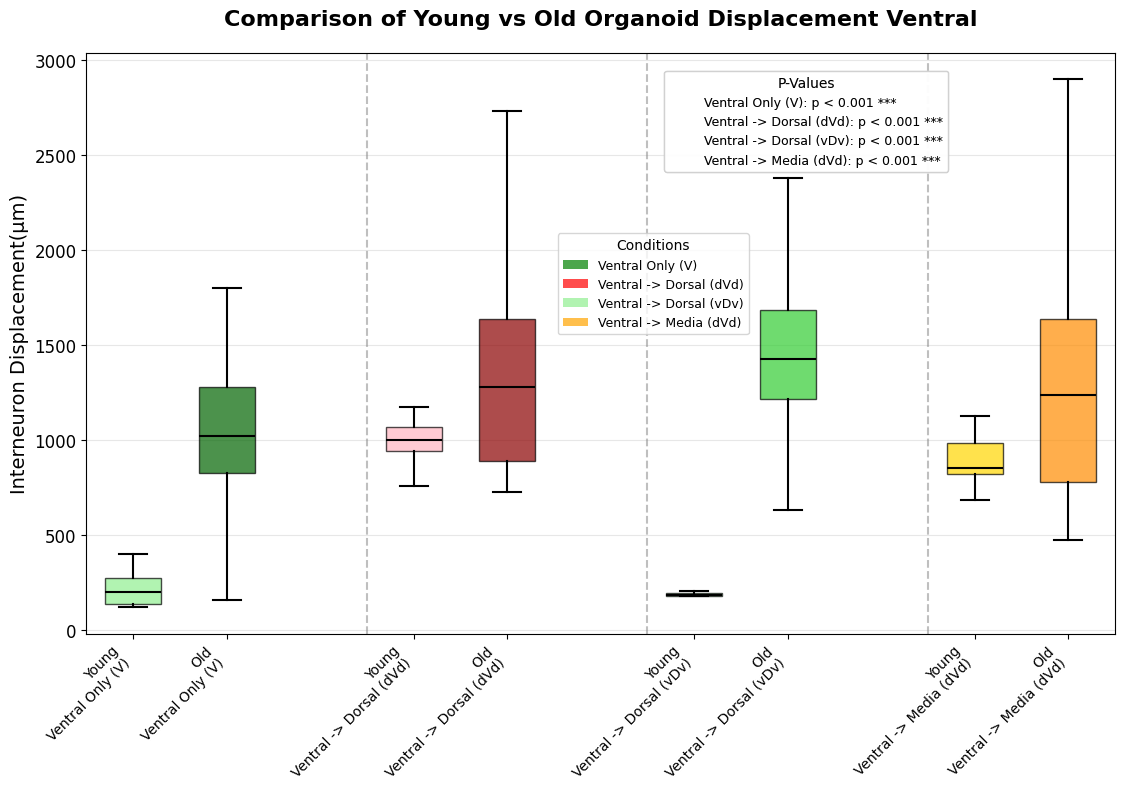

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, Patch
from scipy import stats

# Load the Excel files
df_young = pd.read_excel('Data 1.xlsx', sheet_name='Data 1')
df_old_ventral = pd.read_excel('6 Days Average Ventral Only (3).xlsx', sheet_name='6 Days Ventral Only-Average')
df_old_dvd = pd.read_excel('6 Days dVd average (2).xlsx', sheet_name='6 Days dVd-Average')
df_old_vdv = pd.read_excel('6 days vDv average.xlsx', sheet_name='6 days vDV - Average')

# Clean column names by removing extra spaces
df_young.columns = [col.strip() for col in df_young.columns]
df_old_ventral.columns = [col.strip() for col in df_old_ventral.columns]
df_old_dvd.columns = [col.strip() for col in df_old_dvd.columns]
df_old_vdv.columns = [col.strip() for col in df_old_vdv.columns]

# Combine old organoid data
df_old = pd.concat([df_old_ventral, df_old_dvd, df_old_vdv], axis=1)

# Define the conditions dictionary with colors
conditions = {
    # 1. Ventral only (V)
    'Ventral Only (V)': {
        'columns': ['Condition#1 VentralOnly Green',
                    'Average',
                    'Average.1',
                    'Average.2',
                    'Average.3',
                    'Average.4'
              ],
        'color': 'green'
    },
    # 2. Ventral -> Dorsal (dVd)
    'Ventral -> Dorsal (dVd)': {
        'columns': ['Condition#2 VentralCenter Green',
                    'Ventral-> Dorsal',
                    'Ventral-> Dorsal.1',
                    'Ventral-> Dorsal.2',
                    'Ventral-> Dorsal.3',
                    'Ventral-> Dorsal.4'
        ],
        'color': 'red'
    },
    # 3. Dorsal -> Ventral (vDv)
    'Ventral -> Dorsal (vDv)': {
        'columns': [
            'Condition#4 Dorsal Center Green',
            'Ventral -> Dorsal',
            'Ventral -> Dorsal.1',
            'Ventral -> Dorsal.2',
            'Ventral -> Dorsal.3',
            'Ventral -> Dorsal.4'
        ],
        'color': 'lightgreen'
    },
    # 4. Ventral -> Media (dVd)
    'Ventral -> Media (dVd)': {
        'columns': [
            'Condition#2 VentralCenter toward media',
            'Ventral towards media',
            'Ventral towards media.1',
            'Ventral towards media.2',
            'Ventral towards media.3',
            'Ventral towards media.4'
        ],
        'color': 'orange'
    },
}

# Function to remove outliers using IQR method
def remove_outliers(data):
    if len(data) == 0:
        return np.array([])
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    return data[(data >= lower_bound) & (data <= upper_bound)]

# Prepare data for box plots
plot_data_young = []
plot_data_old = []
clean_condition_names = []
box_colors = []

# Store p-values for each condition
p_values = []

for condition, config in conditions.items():
    # Get valid columns that exist in the young dataframe
    valid_cols_young = [col for col in config['columns'] if col in df_young.columns]

    # Get valid columns that exist in the old dataframe
    valid_cols_old = [col for col in config['columns'] if col in df_old.columns]

    # Process young organoid data
    if valid_cols_young:
        young_velocities = np.abs(df_young[valid_cols_young].values.flatten())
        young_velocities = young_velocities[~np.isnan(young_velocities)]
        clean_young_velocities = remove_outliers(young_velocities)
    else:
        clean_young_velocities = np.array([])

    # Process old organoid data
    if valid_cols_old:
        old_velocities = np.abs(df_old[valid_cols_old].values.flatten())
        old_velocities = old_velocities[~np.isnan(old_velocities)]
        clean_old_velocities = remove_outliers(old_velocities)
    else:
        clean_old_velocities = np.array([])

    if len(clean_young_velocities) > 0 or len(clean_old_velocities) > 0:
        plot_data_young.append(clean_young_velocities)
        plot_data_old.append(clean_old_velocities)
        clean_condition_names.append(condition)
        box_colors.append(config['color'])

        # Calculate p-value for this condition (young vs old)
        if len(clean_young_velocities) > 0 and len(clean_old_velocities) > 0:
            # Use t-test for comparing two groups
            t_stat, p_value = stats.ttest_ind(clean_young_velocities, clean_old_velocities, equal_var=False)
            p_values.append(p_value)
        else:
            p_values.append(np.nan)

# Only proceed if we have data to plot
if plot_data_young or plot_data_old:
    # Create a single figure with both young and old data side by side
    fig, ax = plt.subplots(figsize=(16, 8))

    # Set the positions for the boxes
    positions = []
    group_labels = []
    all_data = []
    box_colors_final = []

    # Prepare data for plotting
    for i, condition in enumerate(clean_condition_names):
        # Young data
        if i < len(plot_data_young) and len(plot_data_young[i]) > 0:
            positions.append(i * 3 + 1)
            all_data.append(plot_data_young[i])
            group_labels.append('Young\n' + condition)
            # Use lighter shade for young
            if box_colors[i] == 'green':
                box_colors_final.append('#90EE90')  # Light green
            elif box_colors[i] == 'red':
                box_colors_final.append('#FFB6C1')  # Light red
            elif box_colors[i] == 'lightgreen':
                box_colors_final.append('#98FB98')  # Pale green
            elif box_colors[i] == 'orange':
                box_colors_final.append('#FFD700')  # Gold (light orange)
            else:
                box_colors_final.append(box_colors[i])

        # Old data
        if i < len(plot_data_old) and len(plot_data_old[i]) > 0:
            positions.append(i * 3 + 2)
            all_data.append(plot_data_old[i])
            group_labels.append('Old\n' + condition)
            # Use darker shade for old
            if box_colors[i] == 'green':
                box_colors_final.append('#006400')  # Dark green
            elif box_colors[i] == 'red':
                box_colors_final.append('#8B0000')  # Dark red
            elif box_colors[i] == 'lightgreen':
                box_colors_final.append('#32CD32')  # Lime green
            elif box_colors[i] == 'orange':
                box_colors_final.append('#FF8C00')  # Dark orange
            else:
                box_colors_final.append(box_colors[i])

    # Create box plot
    box = ax.boxplot(all_data, positions=positions, patch_artist=True, showfliers=False, widths=0.6)

    # Apply custom colors to boxes
    for patch, color in zip(box['boxes'], box_colors_final):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Customize whiskers, caps, etc.
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(box[element], color='black', linewidth=1.5)

    # Customize the plot
    ax.set_title('Comparison of Young vs Old Organoid Displacement Ventral', fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Interneuron Displacement(µm)', fontsize=14)
    ax.set_xticks(positions)
    ax.set_xticklabels(group_labels, rotation=45, ha='right', fontsize=10)
    ax.tick_params(axis='y', labelsize=12)

    # Add grid and adjust layout
    ax.grid(axis='y', alpha=0.3)

    # Add vertical lines to separate conditions
    for i in range(len(clean_condition_names)):
        if i > 0:
            ax.axvline(x=i * 3 + 0.5, color='gray', linestyle='--', alpha=0.5)

    # Create separate legends
    # 1. Legend for condition colors
    condition_legend_elements = []
    for i, condition in enumerate(clean_condition_names):
        condition_legend_elements.append(
            Patch(facecolor=box_colors[i], alpha=0.7, label=condition)
        )

    # 3. Legend for p-values (with asterisks for significance)
    pvalue_legend_elements = []
    for i, condition in enumerate(clean_condition_names):
        if not np.isnan(p_values[i]):
            # Format p-value text with asterisks for significance
            if p_values[i] < 0.001:
                p_text = f'p < 0.001 ***'
            elif p_values[i] < 0.01:
                p_text = f'p < 0.01 **'
            elif p_values[i] < 0.05:
                p_text = f'p < 0.05 *'
            else:
                p_text = f'p = {p_values[i]:.3f}'

            pvalue_legend_elements.append(
                Patch(facecolor='white', alpha=0, label=f"{condition}: {p_text}")
            )
        else:
            pvalue_legend_elements.append(
                Patch(facecolor='white', alpha=0, label=f"{condition}: Not enough data")
            )

    # Add legends to the plot
    legend1 = ax.legend(handles=condition_legend_elements, loc='best',
                         bbox_to_anchor=(0.65, 0.7), title="Conditions", fontsize=9)
    legend3 = ax.legend(handles=pvalue_legend_elements, loc='best',
                         bbox_to_anchor=(0.7, 0.98), title="P-Values", fontsize=9)

    # Manually add the legends to the plot
    ax.add_artist(legend1)
    ax.add_artist(legend3)

    plt.tight_layout()
    plt.subplots_adjust(right=0.7)  # Adjust right margin to accommodate legends

    # Print p-values in console for reference
    print("=" * 60)
    print("P-VALUES FOR EACH CONDITION (Young vs Old)")
    print("=" * 60)
    for i, condition in enumerate(clean_condition_names):
        if not np.isnan(p_values[i]):
            print(f"{condition}: p = {p_values[i]:.6f}")
        else:
            print(f"{condition}: Not enough data for comparison")
    print("=" * 60)

    plt.show()
else:
    print("No valid data found for any condition.")